In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [4]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [5]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [6]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

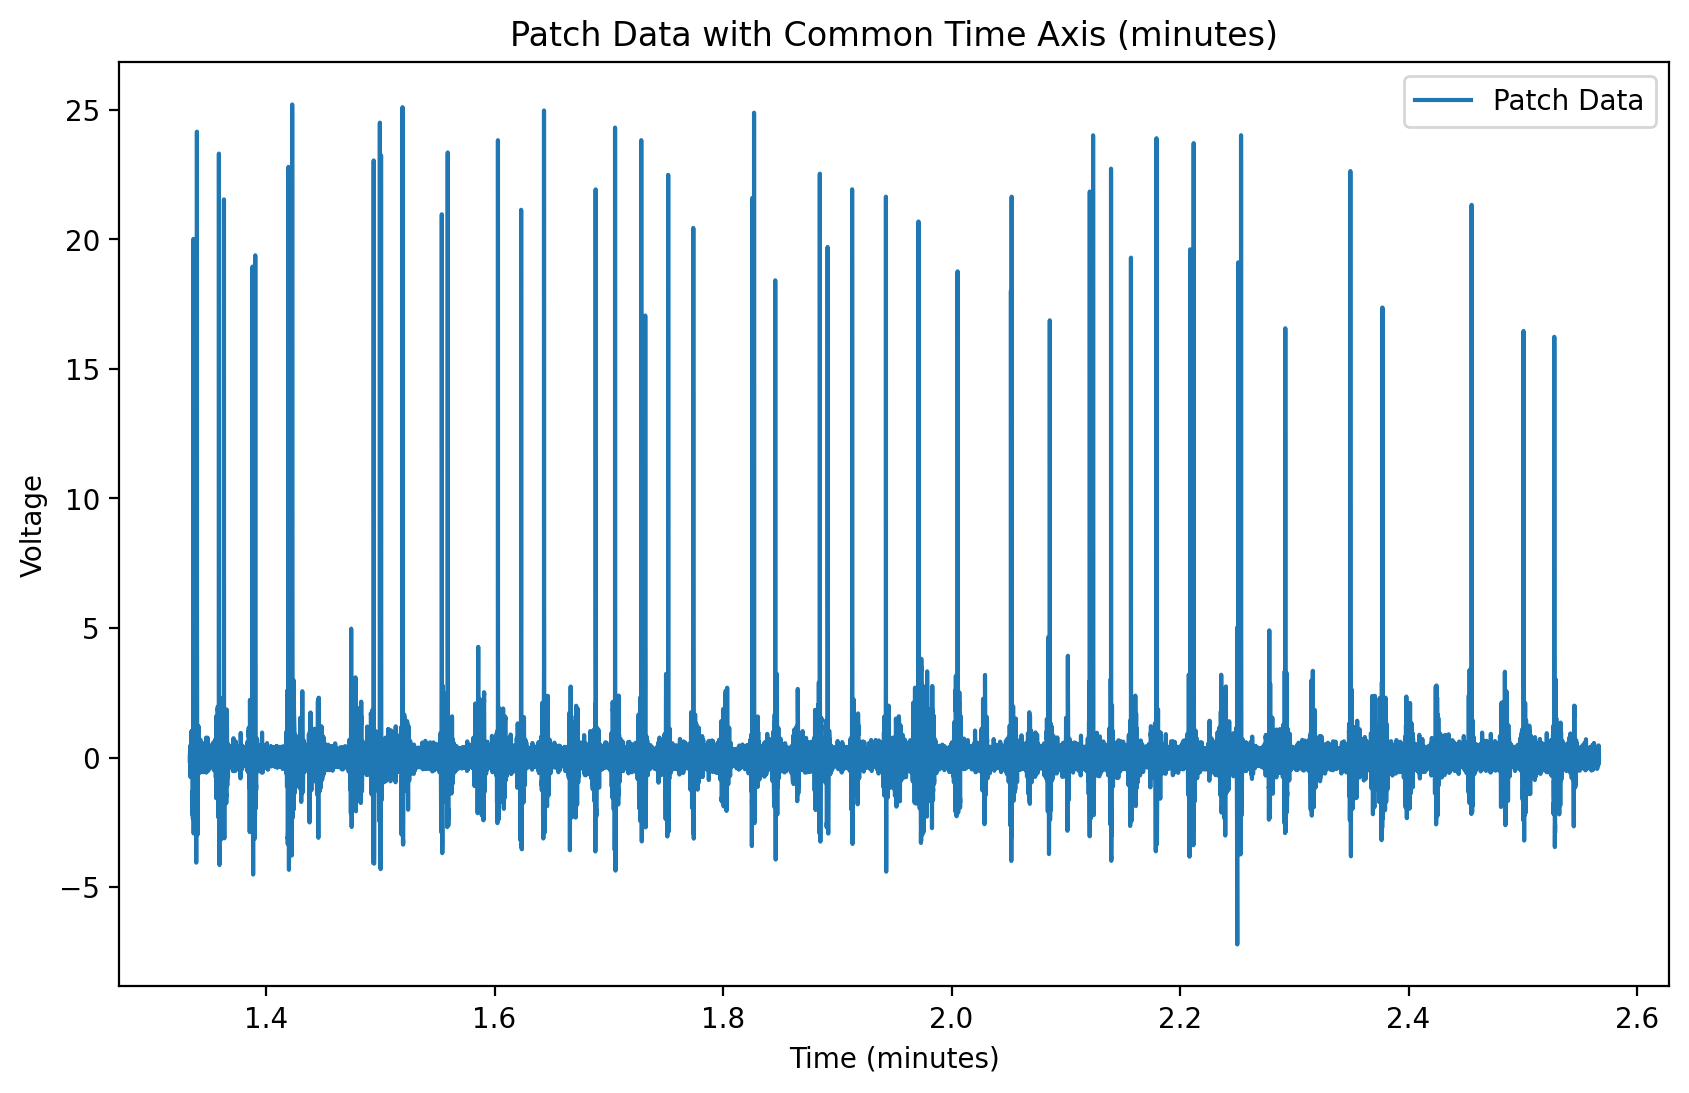

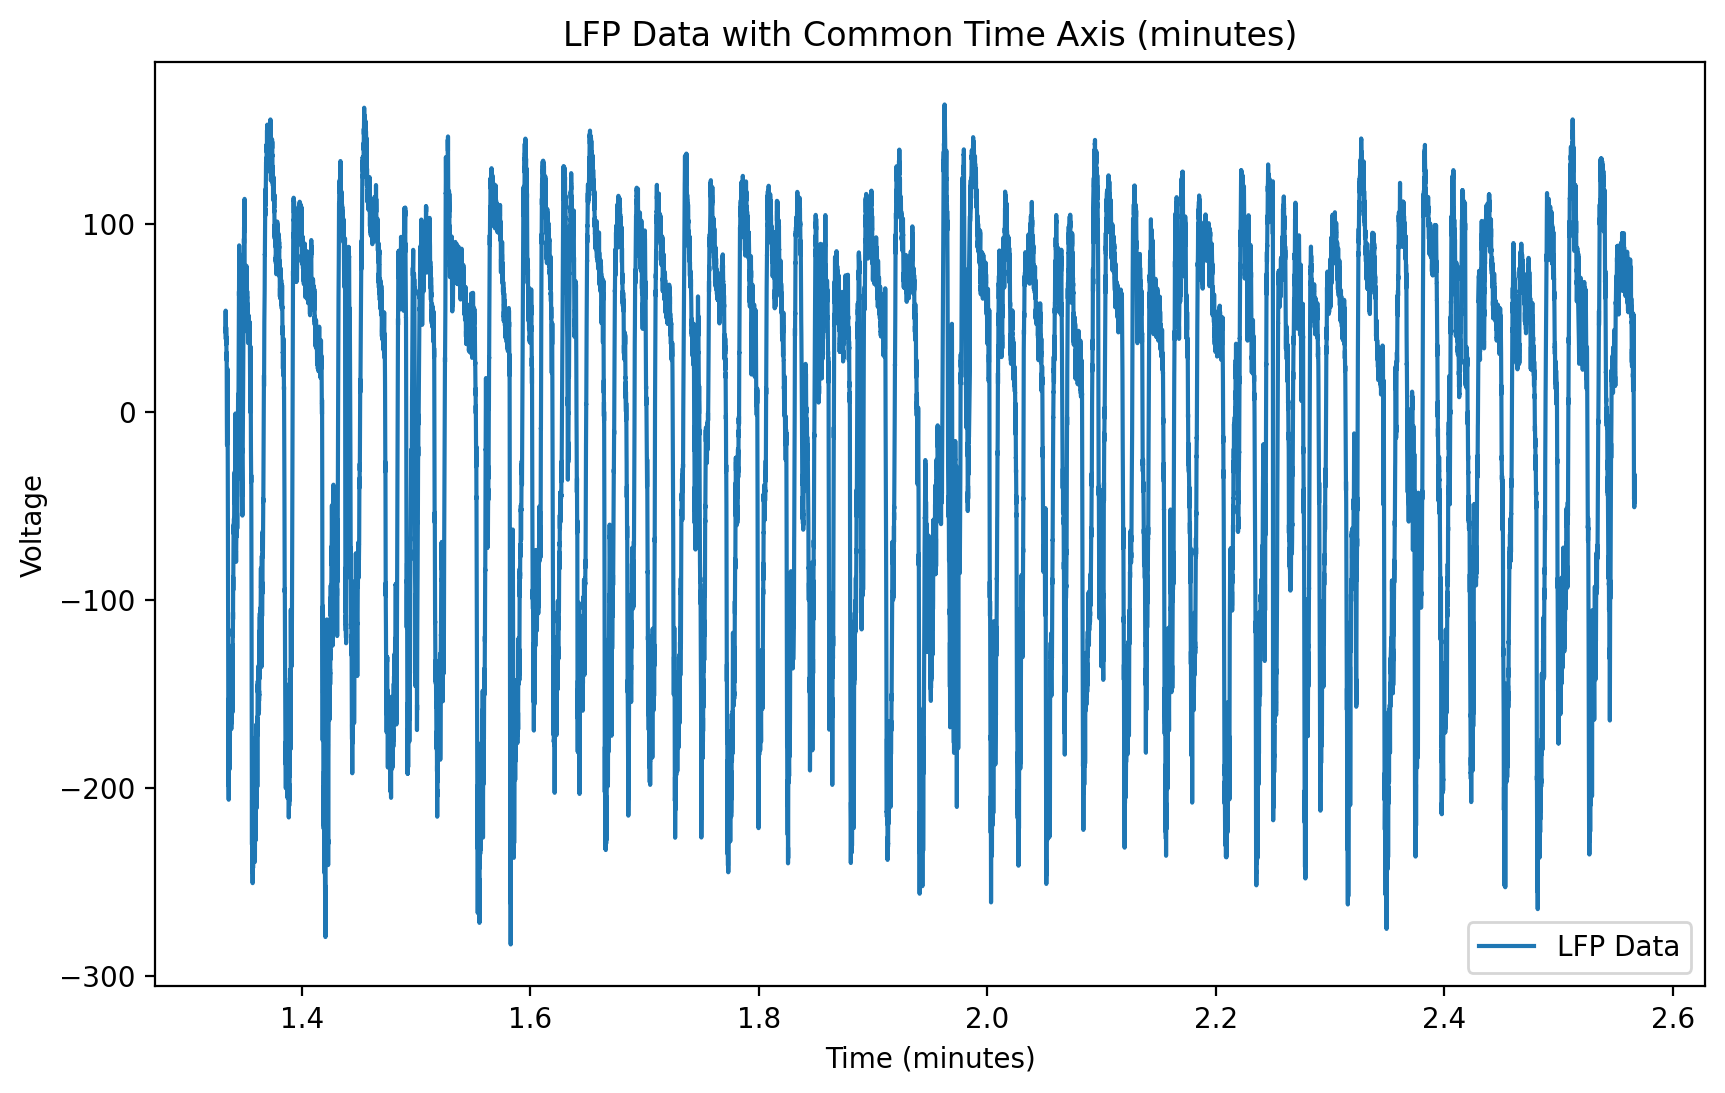

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

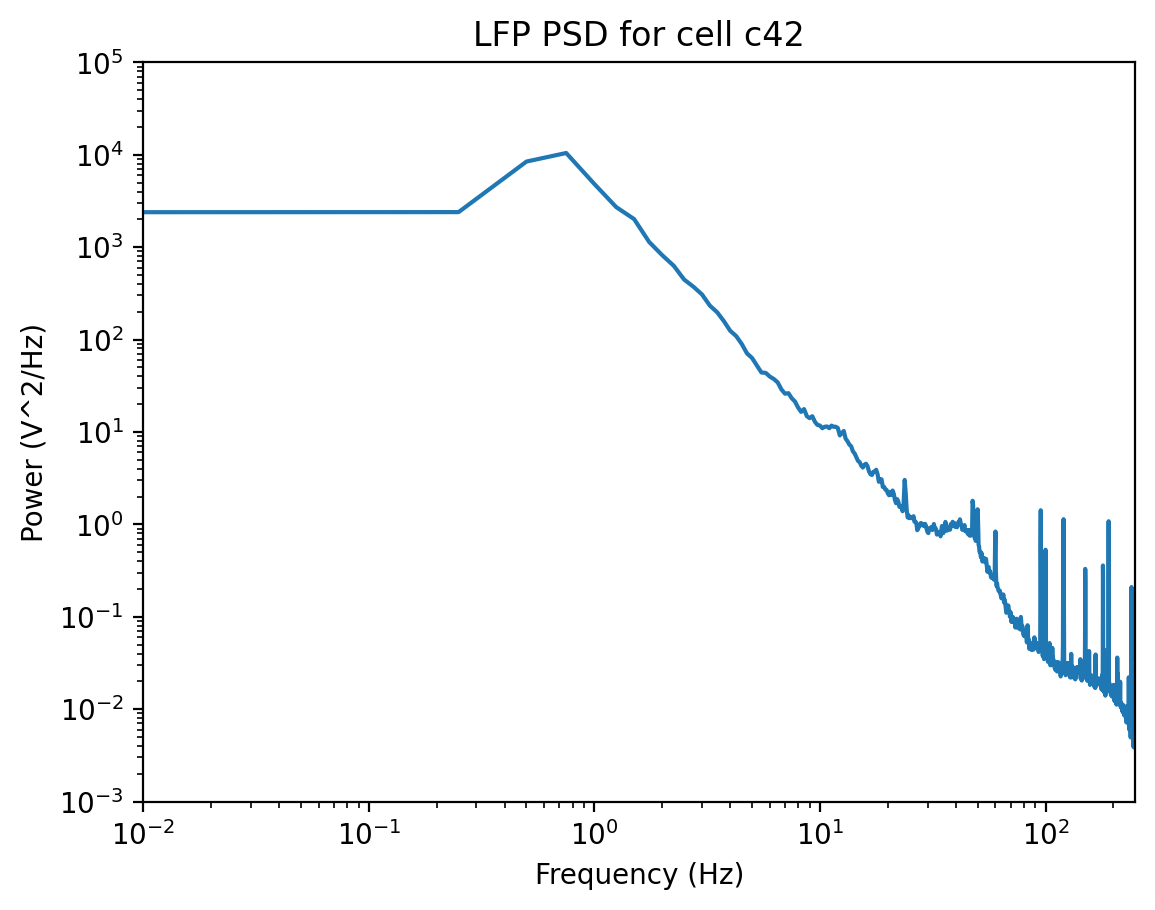

In [8]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


In [9]:
bands = Bands({'gamma' : [30, 55]})

In [353]:
decim_factor = 10

In [407]:
import numpy as np
import mne
from typing import Tuple, List, Literal, Optional
from specparam import SpectralTimeModel
from neurodsp import spectral
from scipy.signal import spectrogram, get_window

def compute_lfp_windows_test(
    lfp_signal: np.ndarray,
    fs: float,
    method: Literal["welch", "multitaper"] = "multitaper",
    # Paper-style defaults:
    window_length_sec: float = 2,             # 2 sec
    freq_range: Tuple[float, float] = (1, 90),
    n_freqs: int = 256,                       # linear freqs (multitaper path)
    time_bandwidth: float = 2.0,              # ~4 Hz half-bandwidth @ 0.5 s (~3 tapers)
    decim_factor: int = 10,                   # step ≈ decim_factor/fs
    # Specparam fit controls:
    progress: bool = True,                    # show Specparam progress bar via tqdm
    n_jobs: int = 1,                          # parallelism for Specparam fit
) -> Tuple[SpectralTimeModel, np.ndarray, List[Tuple[int, int]]]:
    """
    Build spectra across time using either:
      - Welch: explicit sliding windows with nperseg=window_length_sec*fs and step=decim_factor samples
      - Multitaper: tfr_array_multitaper with n_cycles=f*window_length_sec, then one spectrum per time bin

    Returns:
      model         : SpectralTimeModel fit across time bins
      freqs         : frequency vector used
      window_times  : list of (start, end) sample indices per time bin
    """
    win_samps  = int(round(window_length_sec * fs))
    step_samps = max(int(decim_factor), 1)

    if method == "welch":
        # ---- Fast vectorized Welch via scipy.signal.spectrogram (PSD per hop) ----
        # Equivalent to sliding a Hann window of length win_samps with hop=step_samps.
        # scaling='density' matches PSD units; nfft=win_samps to mirror per-window call.
        # Note: spectrogram returns shape (n_freqs, n_bins).
        try:
            # Tiny progress bar (optional)
            if progress:
                try:
                    from tqdm.auto import tqdm
                    tqdm(total=1, desc="Welch PSD", leave=False).update(1)
                except Exception:
                    pass

            fxx, t_bins, Sxx = spectrogram(
                lfp_signal,
                fs=fs,
                window=get_window("hann", win_samps, fftbins=True),
                nperseg=win_samps,
                noverlap=win_samps - step_samps,
                nfft=win_samps,
                detrend=False,
                return_onesided=True,
                scaling="density",
                mode="psd",
            )
            # Limit to requested freq_range to match downstream fit
            sel_f = (fxx >= freq_range[0]) & (fxx <= freq_range[1])
            freqs = fxx[sel_f]
            powers = Sxx[sel_f, :].T  # (n_bins, n_freqs)

            # Reconstruct window start/end sample indices for each bin (like your loop)
            # spectrogram t_bins are centered times in seconds for each segment:
            # center = (start + win_samps/2)/fs  -> start = round(center*fs - win_samps/2)
            start_indices = (np.round(t_bins * fs - win_samps / 2.0)).astype(int)
            window_times = [(int(s), int(s + win_samps)) for s in start_indices]

        except Exception:
            # Fallback to original per-window loop if SciPy path unavailable
            window_times = [
                (start, start + win_samps)
                for start in range(0, max(len(lfp_signal) - win_samps + 1, 0), step_samps)
            ]
            psd_list = []
            freqs = None
            for (start, end) in window_times:
                seg = lfp_signal[start:end]
                fxx, pxx = spectral.compute_spectrum(
                    seg, fs, method="welch",
                    window="hann", nperseg=win_samps
                )
                psd_list.append(pxx)
                if freqs is None:
                    freqs = fxx
            powers = np.asarray(psd_list)  # (n_windows, n_freqs)

    else:
        # ---- Multitaper TFR (already efficient) ----
        freqs = np.linspace(freq_range[0], freq_range[1], int(n_freqs))
        n_cycles = freqs * float(window_length_sec)
        tb = max(float(time_bandwidth), 2.0)  # ensure ≥ ~3 tapers

        # Cast to float32 to reduce memory / bandwidth
        epochs = lfp_signal.astype(np.float32, copy=False)[np.newaxis, np.newaxis, :]  # (1, 1, n_times)
        tfr = mne.time_frequency.tfr_array_multitaper(
            epochs, sfreq=fs, freqs=freqs, n_cycles=n_cycles,
            time_bandwidth=tb, output="power", decim=decim_factor, verbose=False
        )                                              # (1, 1, n_freqs, n_bins)
        spec = np.squeeze(tfr, axis=(0, 1))            # (n_freqs, n_bins)
        powers = spec.T                                # (n_bins, n_freqs)

        # Window times aligned to TFR bins (step = decim_factor samples)
        n_bins = powers.shape[0]
        window_times = [(i * step_samps, i * step_samps + win_samps) for i in range(n_bins)]

    # ---- Specparam fit with built-in progress bar ----
    powers_T = powers.T  # (n_freqs, n_windows)
    model = SpectralTimeModel(peak_width_limits=(4, 8), max_n_peaks=4)

    progress_arg = 'tqdm' if progress else None  # requires `tqdm` installed
    model.fit(
        freqs=freqs,
        spectrogram=powers_T,
        freq_range=freq_range,
        n_jobs=n_jobs,
        progress=progress_arg,
    )

    return model, freqs, window_times


###### SLIDING WINDOWS APPROACH - Multitaper

In [408]:
model_mt, freqs_mt, window_times_mt = compute_lfp_windows_test(
    lfp_signal=lfp_filt,
    window_length_sec = 0.1,
    freq_range = (5, 90),
    fs=lfp_fs,
    method="multitaper",
    decim_factor = decim_factor
)

summary_df_multitaper = model_mt.to_df()

Running group fits.: 100%|████████████| 202509/202509 [4:00:17<00:00, 14.05it/s]


In [409]:
#save as pickle
with open('mtc42_model_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(model_mt, file)

with open('mtc42_freqs_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(freqs_mt, file)

with open('mtc42_window_times_mt_shortwin.pkl', 'wb') as file:
    pickle.dump(window_times_mt, file)

In [360]:
#open pickle
with open('mtc42_model_mt_shortwin.pkl', 'rb') as file:
    model_mt = pickle.load(file)

with open('mtc42_freqs_mt_shortwin.pkl', 'rb') as file:
    freqs_mt = pickle.load(file)

with open('mtc42_window_times_mt_shortwin.pkl', 'rb') as file:
    window_times_mt = pickle.load(file)

                                                                                                  
                                           TIME RESULTS                                           
                                                                                                  
                                Number of time windows fit: 202509                                
                                                                                                  
                        The model was run on the frequency range 5 - 90 Hz                        
                                 Frequency Resolution is 0.33 Hz                                  
                                                                                                  
                              Power spectra were fit without a knee.                              
                                                                                                  
          

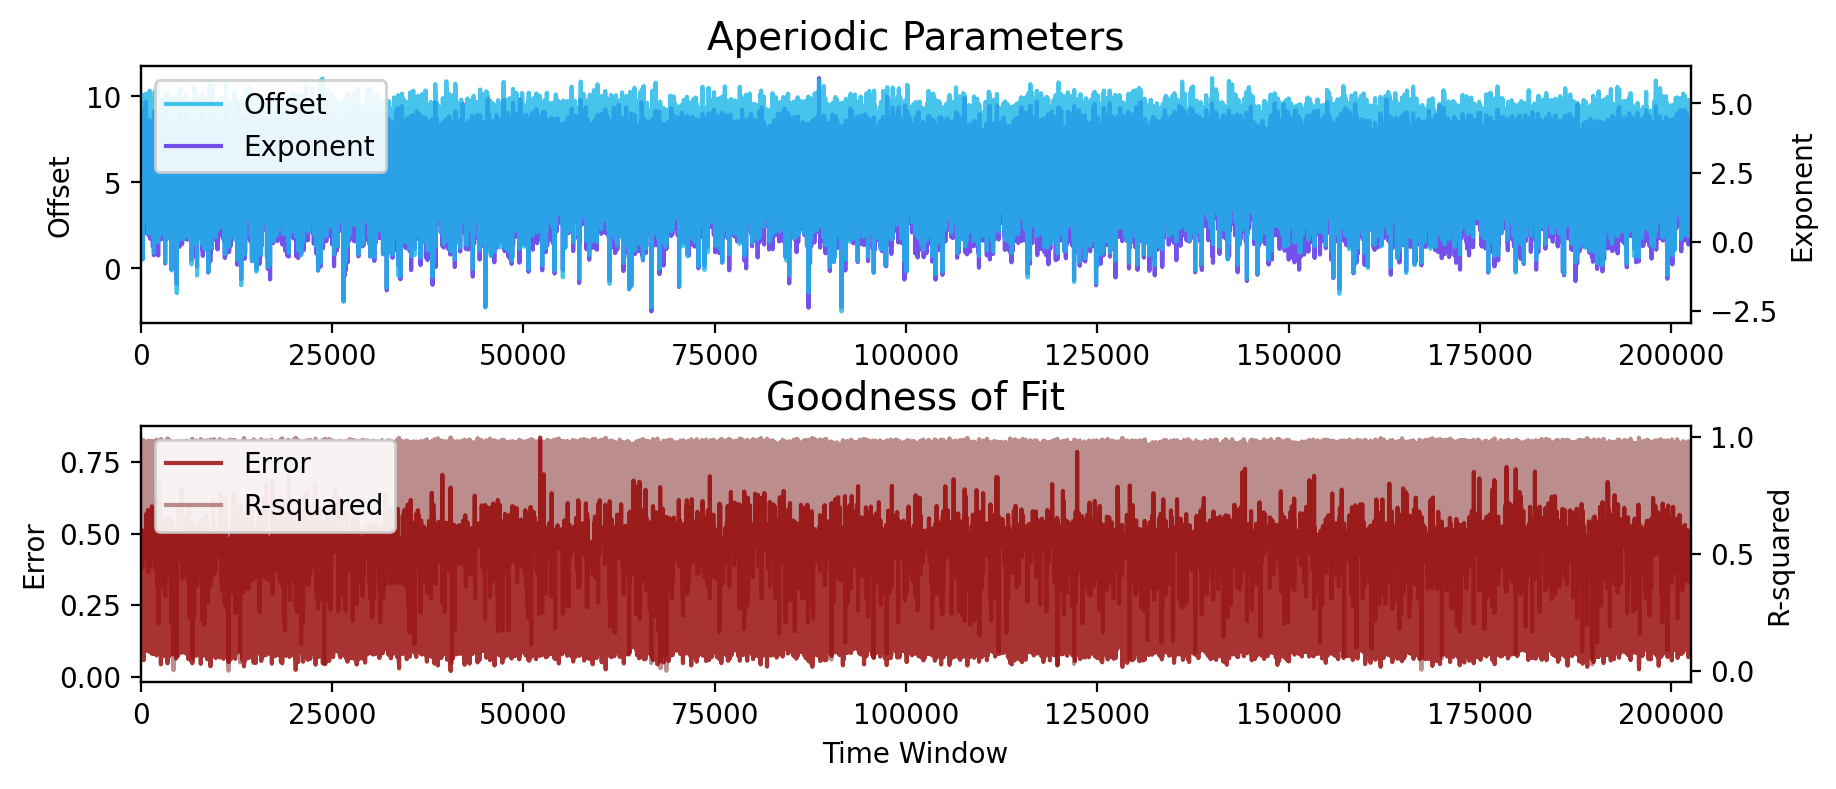

In [410]:
model_mt.print_results(
)
model_mt.plot(peak_org=bands)

In [411]:
# Existing summary from specparam (offset, exponent, r_squared, error, n_peaks, etc.)
summary_df_multitaper = model_mt.to_df().reset_index(drop=True)



In [412]:
summary_df_multitaper

,offset,exponent,error,r_squared
0,7.153107,2.428725,0.061090,0.990344
1,7.152117,2.449894,0.066959,0.990204
2,7.260948,2.558540,0.095560,0.980327
3,7.180976,2.442243,0.150732,0.955086
4,6.971636,2.380620,0.074867,0.985068
...,...,...,...,...
202504,6.532741,2.710860,0.292125,0.847974
202505,6.054628,2.393857,0.232761,0.881645
202506,6.521595,2.677669,0.268711,0.877058
202507,6.542565,2.683469,0.197157,0.926250


## STEP 2: Get AUC gamma (subtract off the aperiodic exponent from the raw spectrum)

In [413]:
#compute gamma AUC + exponent per window 
specp_auc_df = gamma_auc_and_exponent_per_window(model_mt, band=(25, 60), space="log")

Computing gamma AUC + exponent:   0%|          | 0/202509 [00:00<?, ?it/s]

In [414]:
specp_auc_df

,win_idx,gamma_auc,aperiodic_exponent
0,0,6.933019,2.428725
1,1,8.087765,2.449894
2,2,8.667567,2.558540
3,3,0.352573,2.442243
4,4,6.659239,2.380620
...,...,...,...
202504,202504,19.903571,2.710860
202505,202505,17.062388,2.393857
202506,202506,14.285919,2.677669
202507,202507,11.476708,2.683469


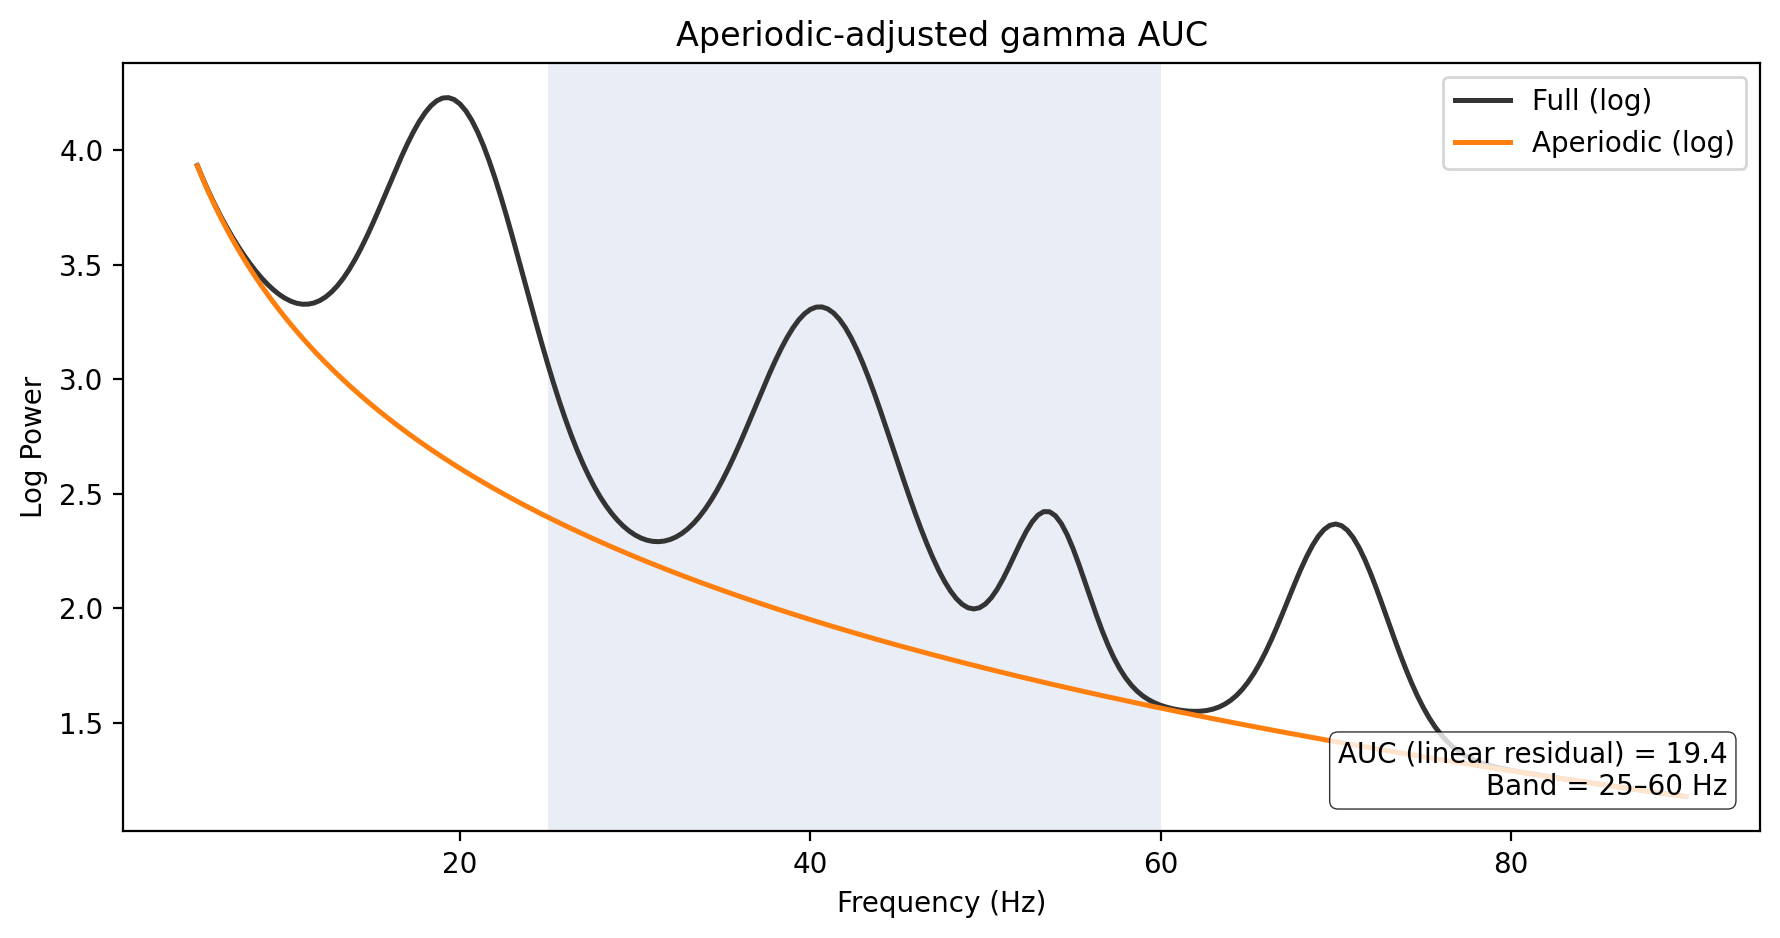

In [424]:
#Show example of process for one window idx
auc_val = plot_log_spectra_and_auc(
    model_mt,
    win_idx=70504,
    band=(25, 60),
    freq_range=(5, 90),   # optional, for display only
    title="Aperiodic-adjusted gamma AUC"
)


## STEP 3: Detect spikes from patch data

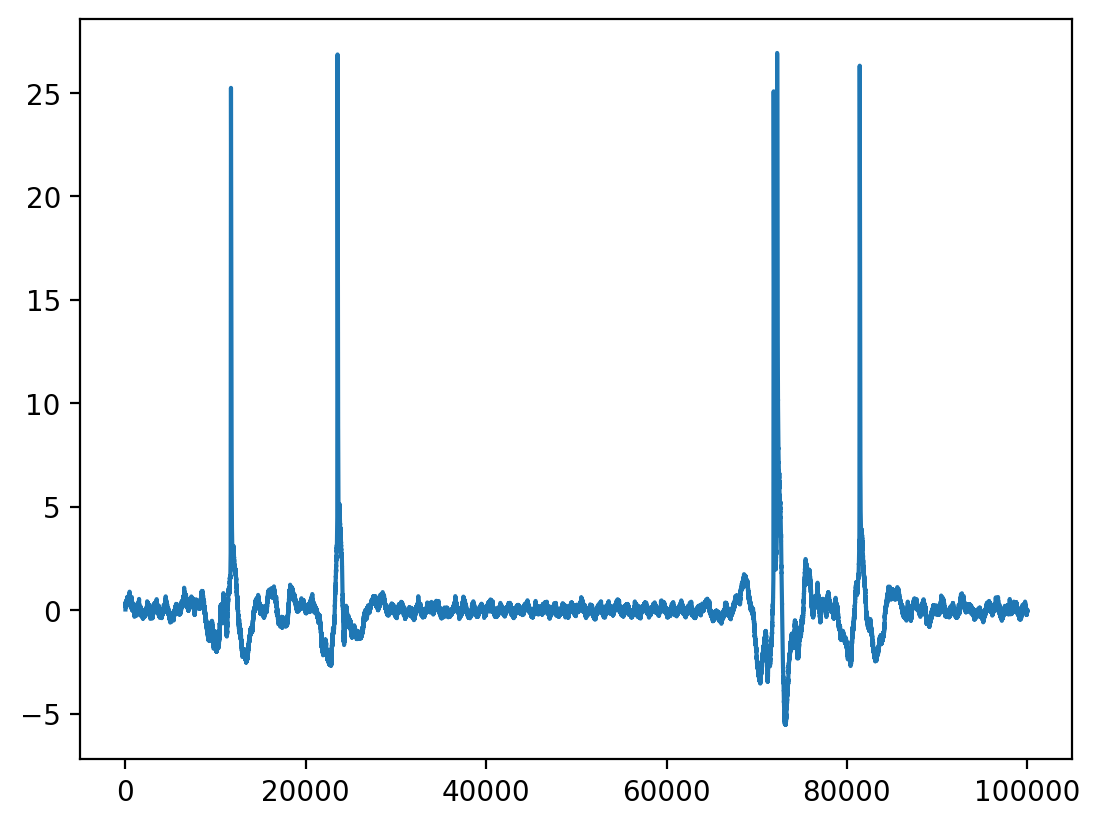

In [426]:
plt.plot(patch_filt[:100000] )

In [427]:



#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

In [428]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/626 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


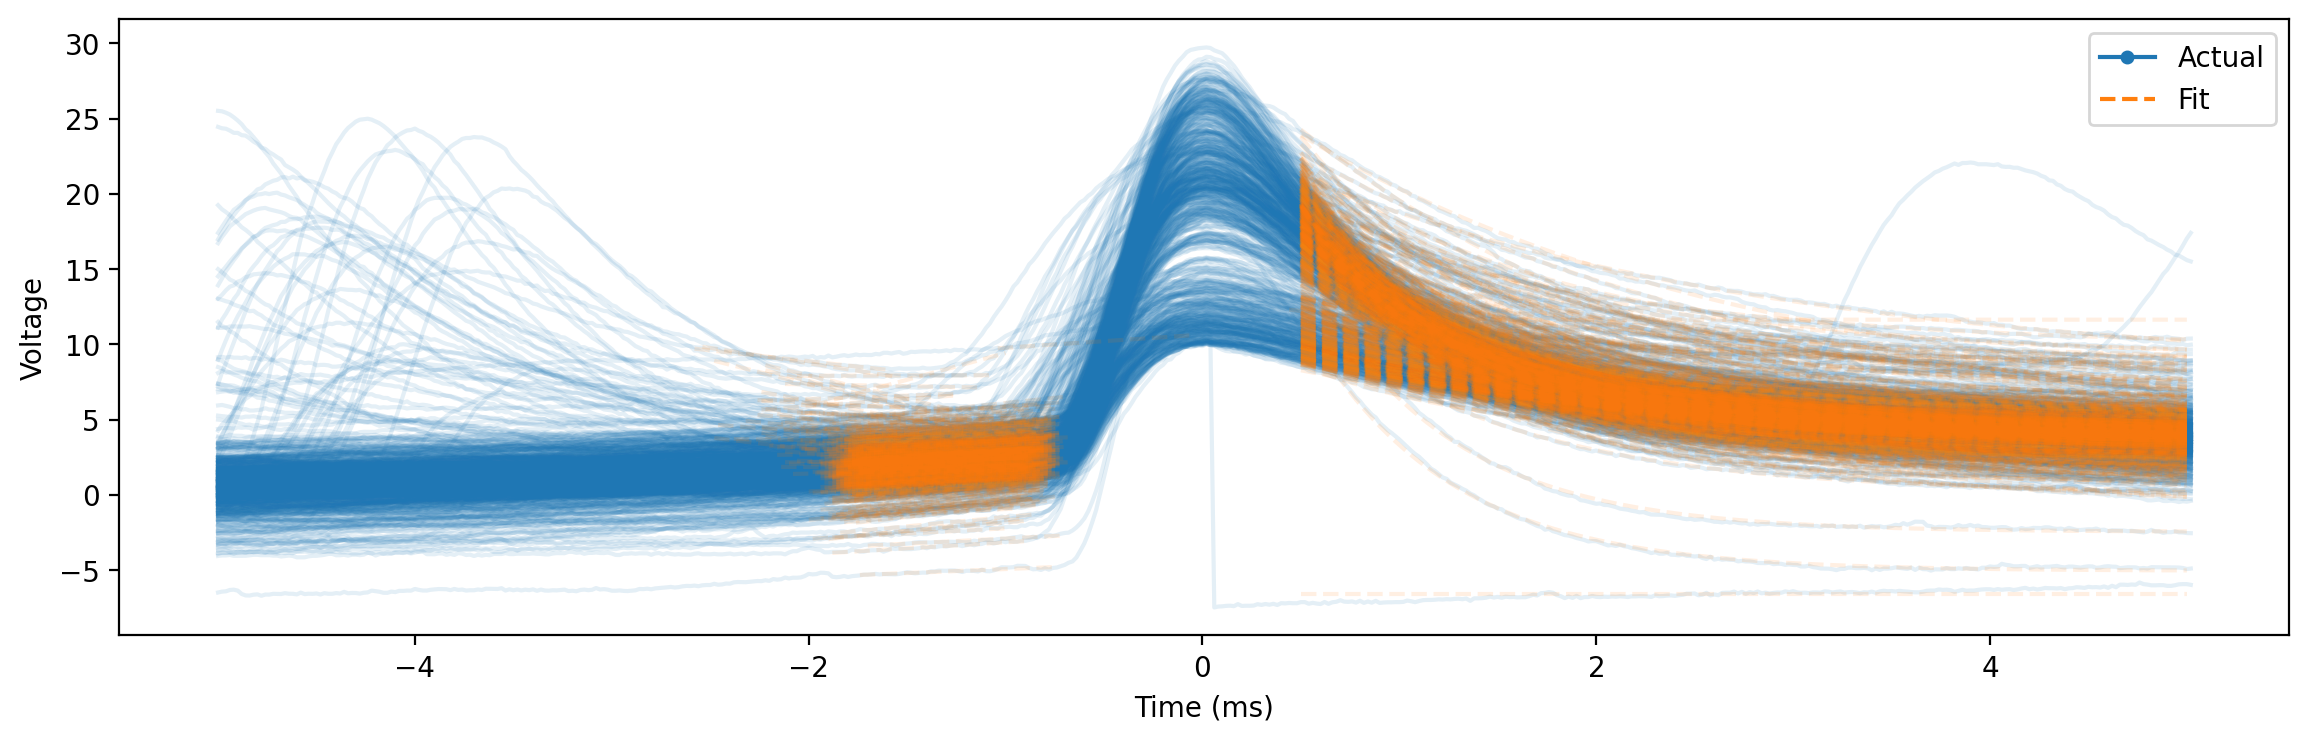

In [429]:
sp.plot()

### Filter spikes 

In [430]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [431]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [432]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367,11705,233.988239,0
1,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771,23523,470.235400,1
2,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434,72270,1444.709957,2
3,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033,81424,1627.702554,3
4,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045,149534,2989.252231,4
...,...,...,...,...,...,...,...,...,...,...,...,...
620,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371,37325628,746156.170373,606
621,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366,37720584,754051.519285,607
622,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649,37825912,756157.073600,608
624,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976,38708847,773807.343230,609


### Get spike times


In [433]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 4: Get avg waveform and for every spike, calculate error (aligned to peak)

In [434]:
#get root mean squared errors
errs = spike_waveform_errors(sp, metric="rmse") 


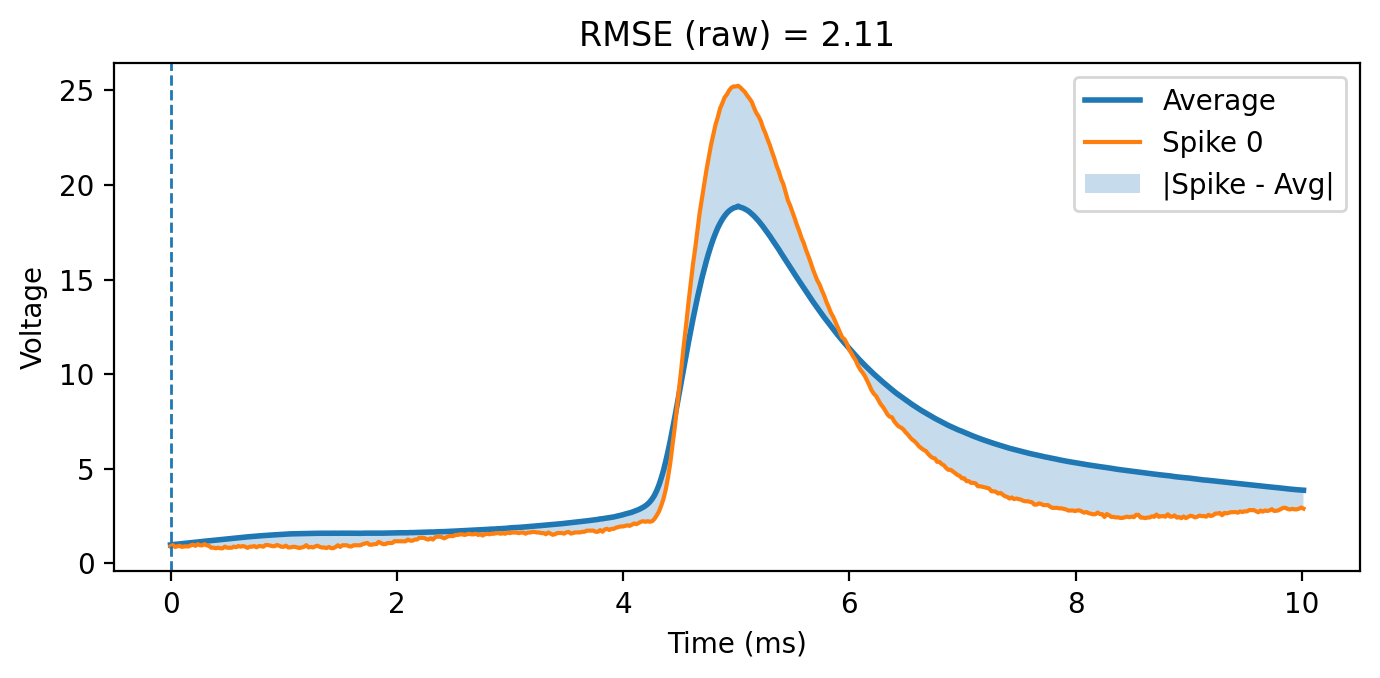

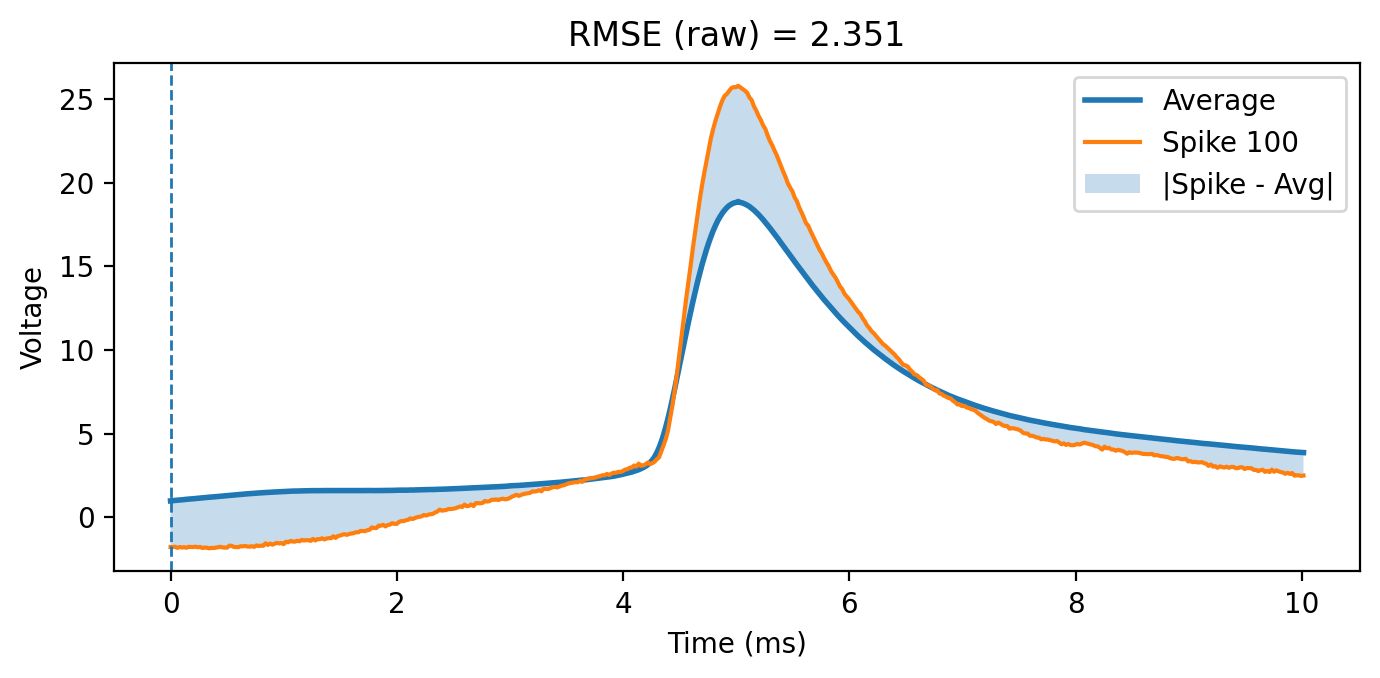

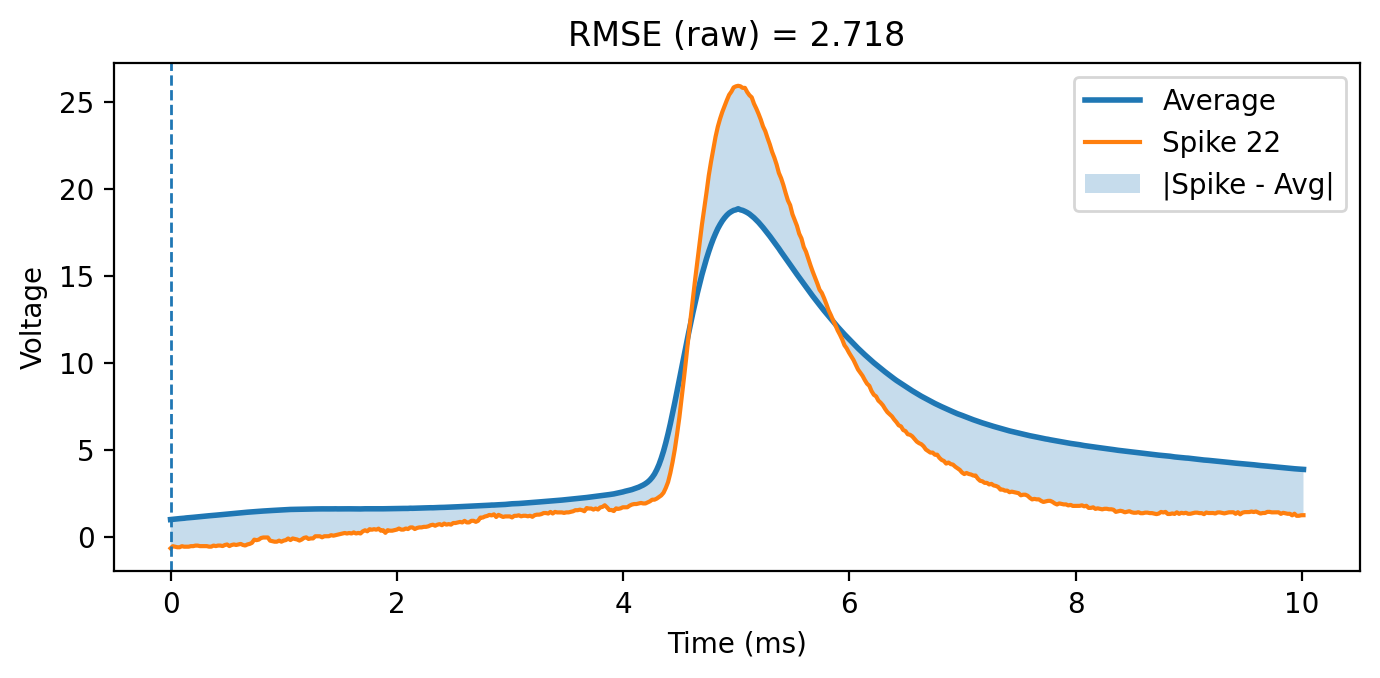

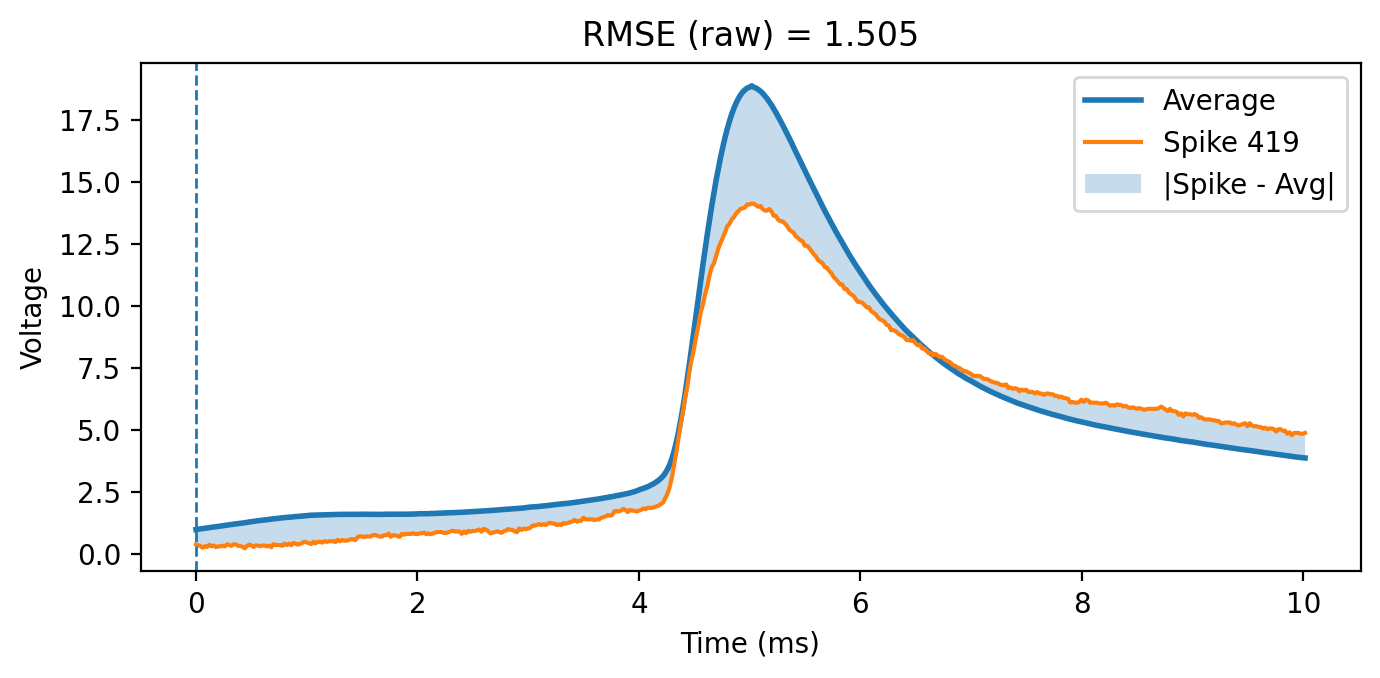

In [435]:
#Examples
e = visualize_spike_error(sp, spike_idx=0, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=100, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=22, metric="rmse", show_residual=True)
e = visualize_spike_error(sp, spike_idx=419, metric="rmse", show_residual=True)


## STEP 4: Map spikes to windows and create df with spike error, LFP AUC and aperiodic exponent

In [436]:
#generate df with spike waveform errors, lfp window auc and aperiodic exponent
spike_lfp_df = make_spike_waveform_error_and_auc_df(errs, df_features, window_times_mt, lfp_fs, specp_auc_df)


In [437]:
spike_lfp_df

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent
0,0,233.988239,2.110317,58.0,16.901377,3.025995
1,1,470.235400,2.130798,117.0,24.173628,3.236983
2,2,1444.709957,3.184825,361.0,21.368298,2.395479
3,3,1627.702554,2.002792,406.0,15.209696,1.424164
4,4,2989.252231,2.188142,747.0,12.898314,2.628116
...,...,...,...,...,...,...
606,606,746156.170373,3.085849,186539.0,14.444554,1.842828
607,607,754051.519285,2.752751,188512.0,24.633706,3.130676
608,608,756157.073600,3.498201,189039.0,26.049858,1.650328
609,609,773807.343230,3.569605,193451.0,17.592463,2.081525


Text(0, 0.5, 'gamma auc')

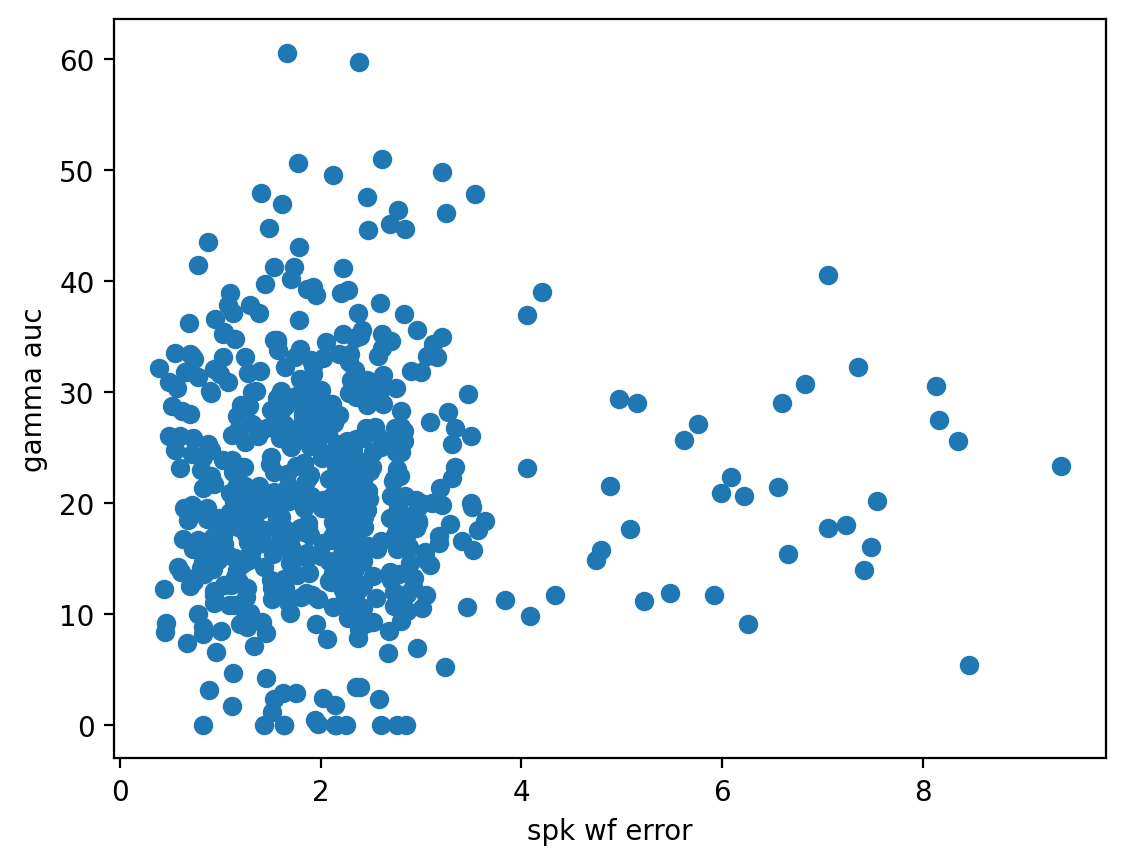

In [438]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['gamma_auc'])
plt.xlabel("spk wf error")
plt.ylabel("gamma auc")

Text(0, 0.5, 'aperiodic exponent')

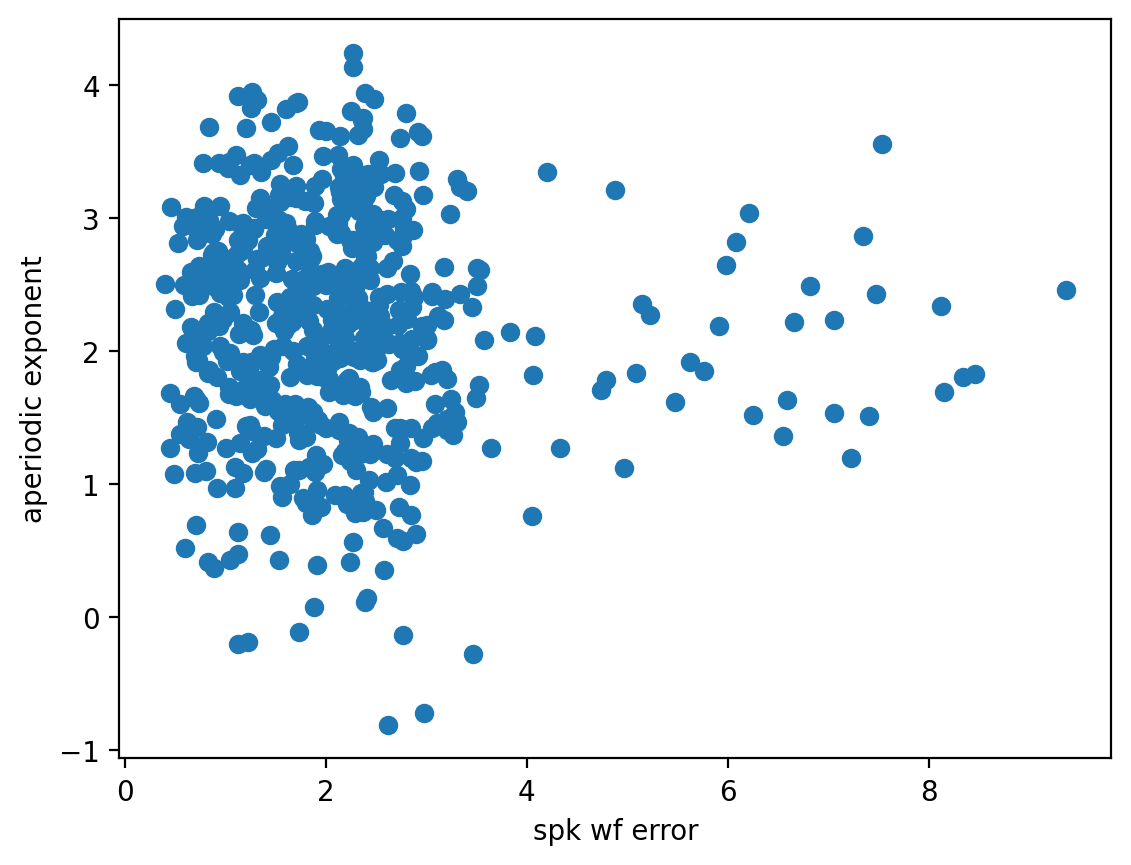

In [439]:
plt.scatter(spike_lfp_df['wf_error'], spike_lfp_df['aperiodic_exponent'])
plt.xlabel("spk wf error")
plt.ylabel("aperiodic exponent")

## STEP 5: Build regression to predict per-spike error as a combination of the gamma AUC and the aperiodic exponent - RIP - didn't work

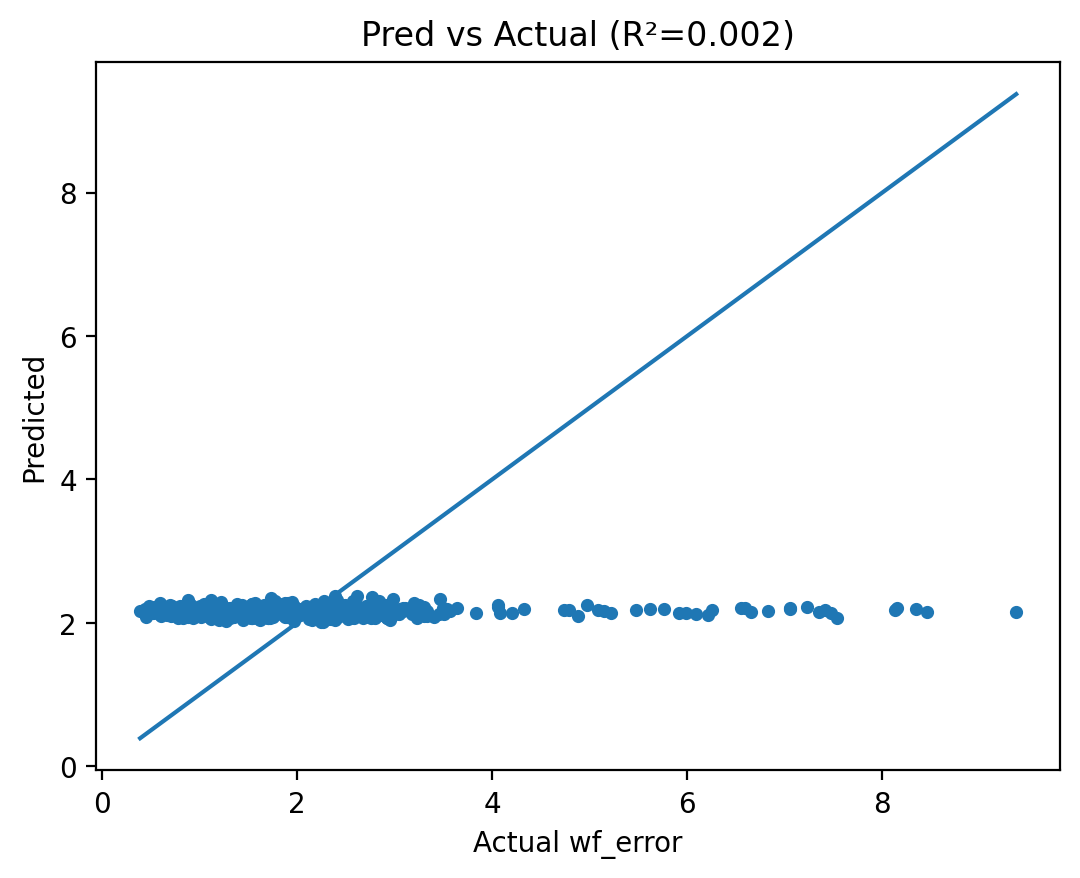

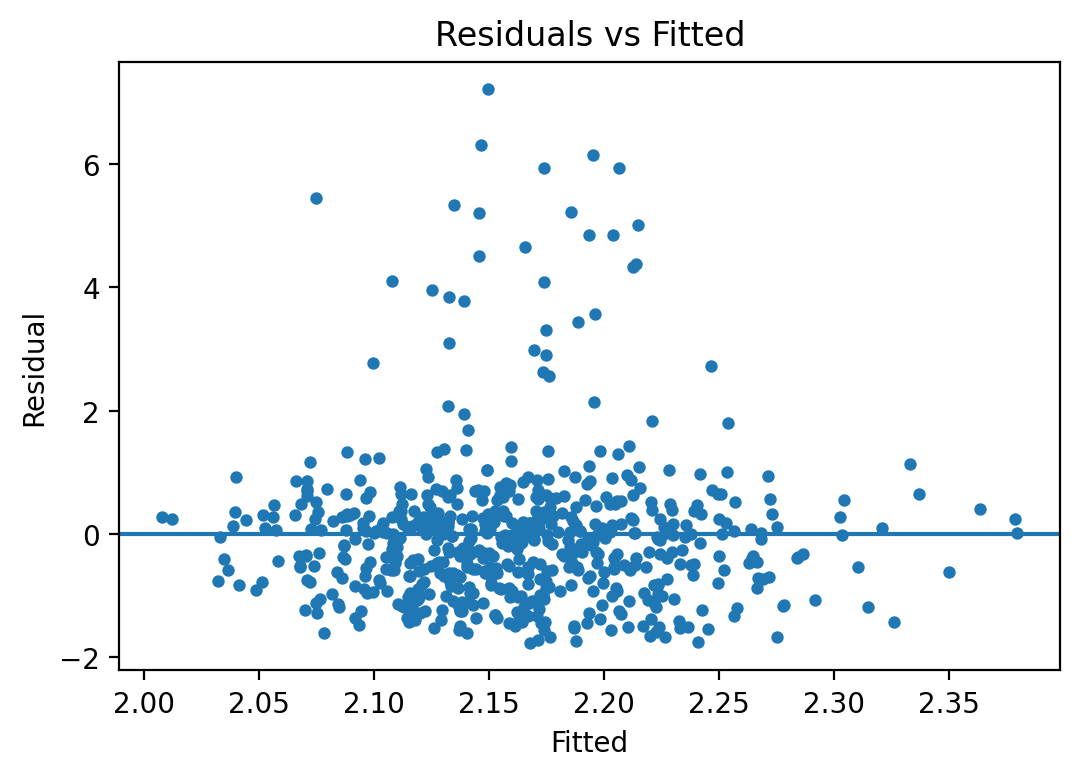

                        coef        se          z     P>|z|     ci_lo  \
const               2.162008  0.051774  41.758700  0.000000  2.060533   
gamma_auc           0.023215  0.047794   0.485723  0.627164 -0.070460   
aperiodic_exponent -0.051709  0.043730  -1.182463  0.237022 -0.137417   

                       ci_hi  
const               2.263483  
gamma_auc           0.116889  
aperiodic_exponent  0.034000  


In [440]:
res = fit_linear_regression(
    spike_lfp_df,
    y_col="wf_error",
    x_cols=["gamma_auc", "aperiodic_exponent"],
    standardize=True,
    interactions=False,
    robust_se=True,
    do_cv=True,
    cv_splits=5,
    plot=True,
)
print(res["coefs"])


### STEP 6: See if AUC and aperiodic exponent correlate with spike params 

In [441]:
#create combined df with new LFP features and spike params 

#make sure the left DF has a 'spk_id' column to join on
spike_lfp_df_ = spike_lfp_df.copy()
if "spk_id" not in spike_lfp_df_.columns and "pk_id" in spike_lfp_df_.columns:
    spike_lfp_df_ = spike_lfp_df_.rename(columns={"pk_id": "spk_id"})

# select the feature columns you want from df_features (index by spk_id for a clean join)
feat_cols = [
    "ramp_amp",
    "inflection_time",
    "inflection_amp",
    "peak_amp",
    "peak_width",
    "peak_sharpness",
    "exp_lambda",
    "exp_const",
    "log_isi",
]
feat = df_features.set_index("spk_id")[feat_cols]

# left join by spk_id
spike_lfp_with_feats = spike_lfp_df_.join(feat, on="spk_id", how="left")




In [442]:
spike_lfp_with_feats

,spk_id,spk_times_ms,wf_error,win_idx,gamma_auc,aperiodic_exponent,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi
0,0,233.988239,2.110317,58.0,16.901377,3.025995,0.655520,0.76,2.234912,25.207082,1.24,0.532077,1.323753,2.357226,2.373367
1,1,470.235400,2.130798,117.0,24.173628,3.236983,0.830898,0.70,3.834110,26.766186,1.14,0.717454,1.616296,4.364779,2.988771
2,2,1444.709957,3.184825,361.0,21.368298,2.395479,0.514807,0.84,3.345557,26.927673,1.54,0.423752,0.981911,6.132088,2.262434
3,3,1627.702554,2.002792,406.0,15.209696,1.424164,1.131318,0.72,3.423346,26.219775,1.14,0.626201,1.488794,3.536553,3.134033
4,4,2989.252231,2.188142,747.0,12.898314,2.628116,1.095346,0.72,3.602710,27.026259,1.20,0.577308,1.179299,3.795708,3.238045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,606,746156.170373,3.085849,186539.0,14.444554,1.842828,-0.265376,1.02,2.682118,10.791884,4.22,0.106704,0.380376,5.169002,3.897371
607,607,754051.519285,2.752751,188512.0,24.633706,3.130676,0.517355,0.70,3.353721,10.312721,1.78,0.165035,0.585853,3.846416,3.323366
608,608,756157.073600,3.498201,189039.0,26.049858,1.650328,-0.909968,1.02,4.727512,11.676022,3.28,0.151212,0.276106,4.721465,3.219649
609,609,773807.343230,3.569605,193451.0,17.592463,2.081525,-0.175349,1.08,4.097930,11.829634,3.78,0.121415,0.237549,4.137374,4.340976


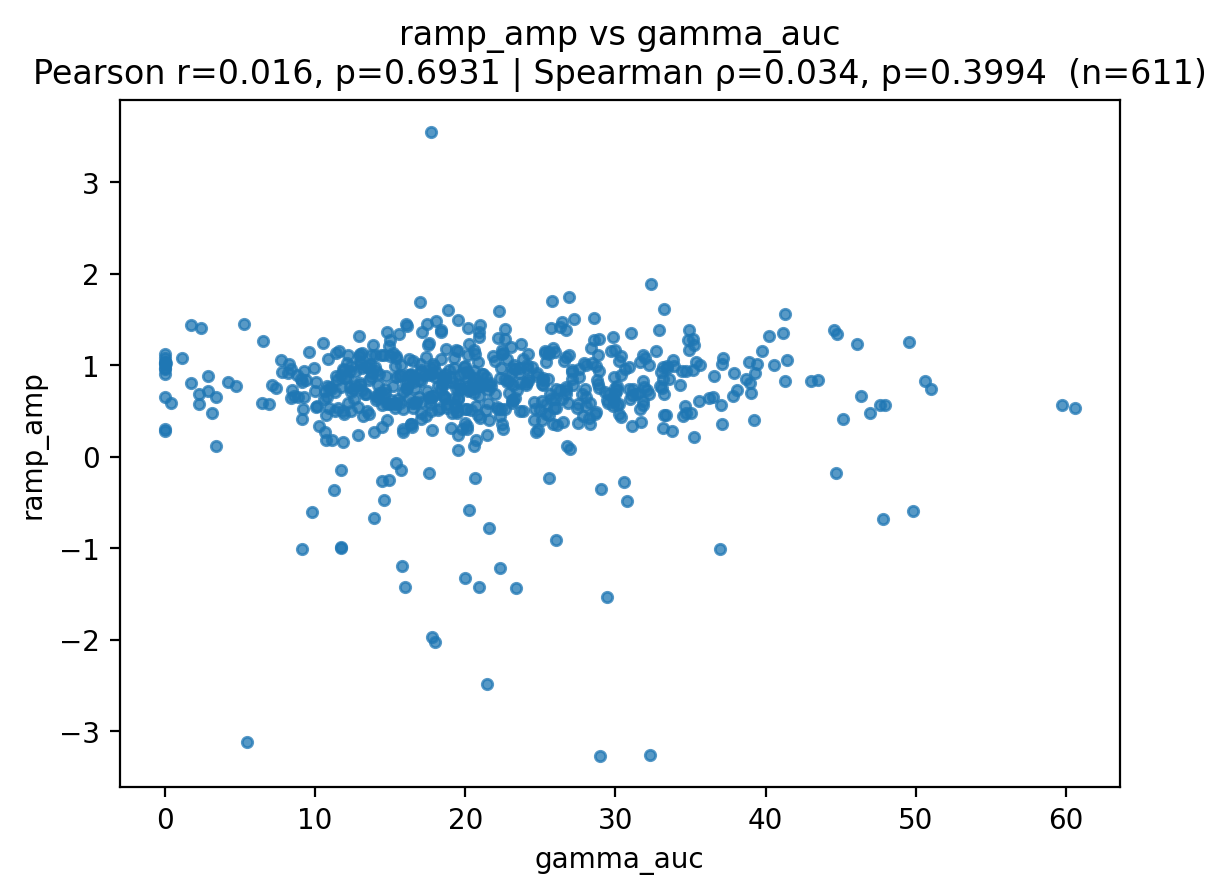

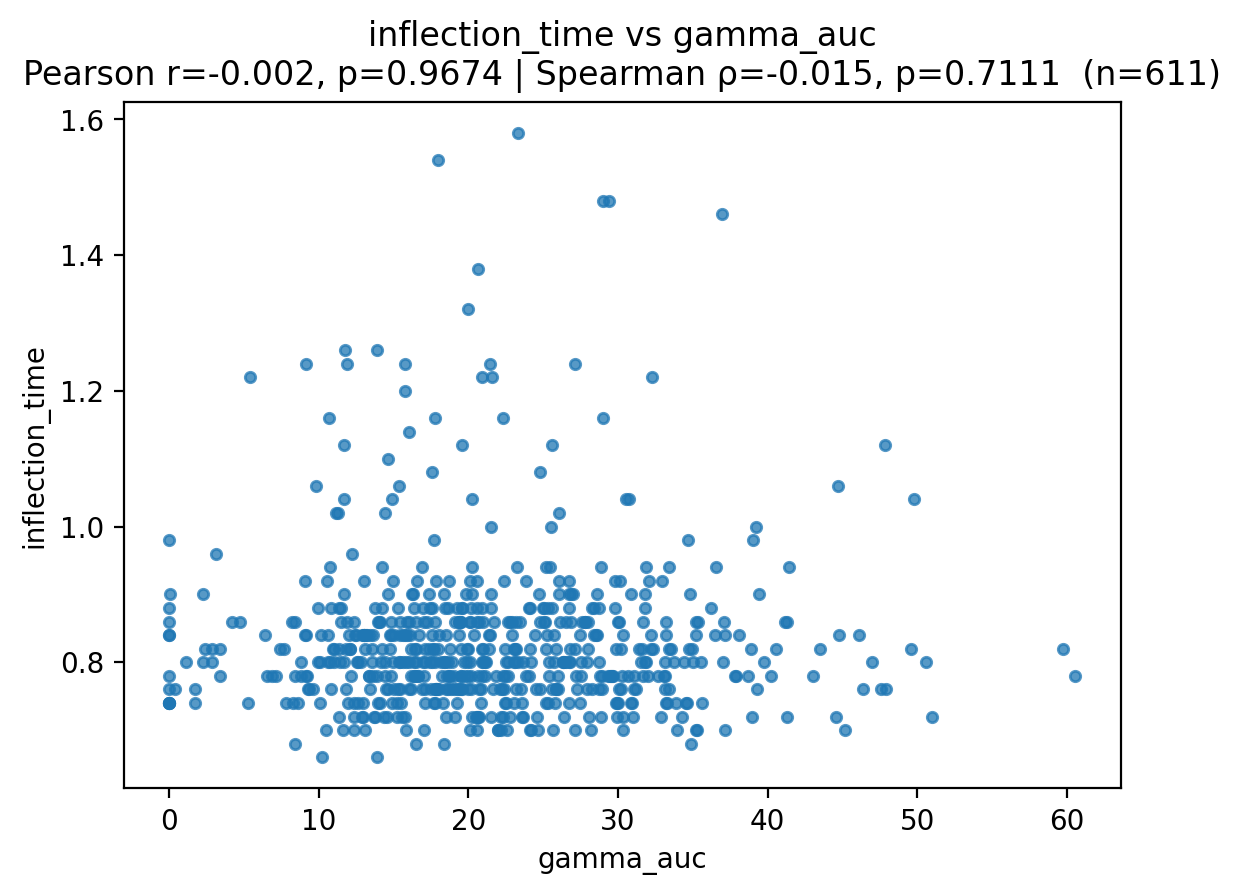

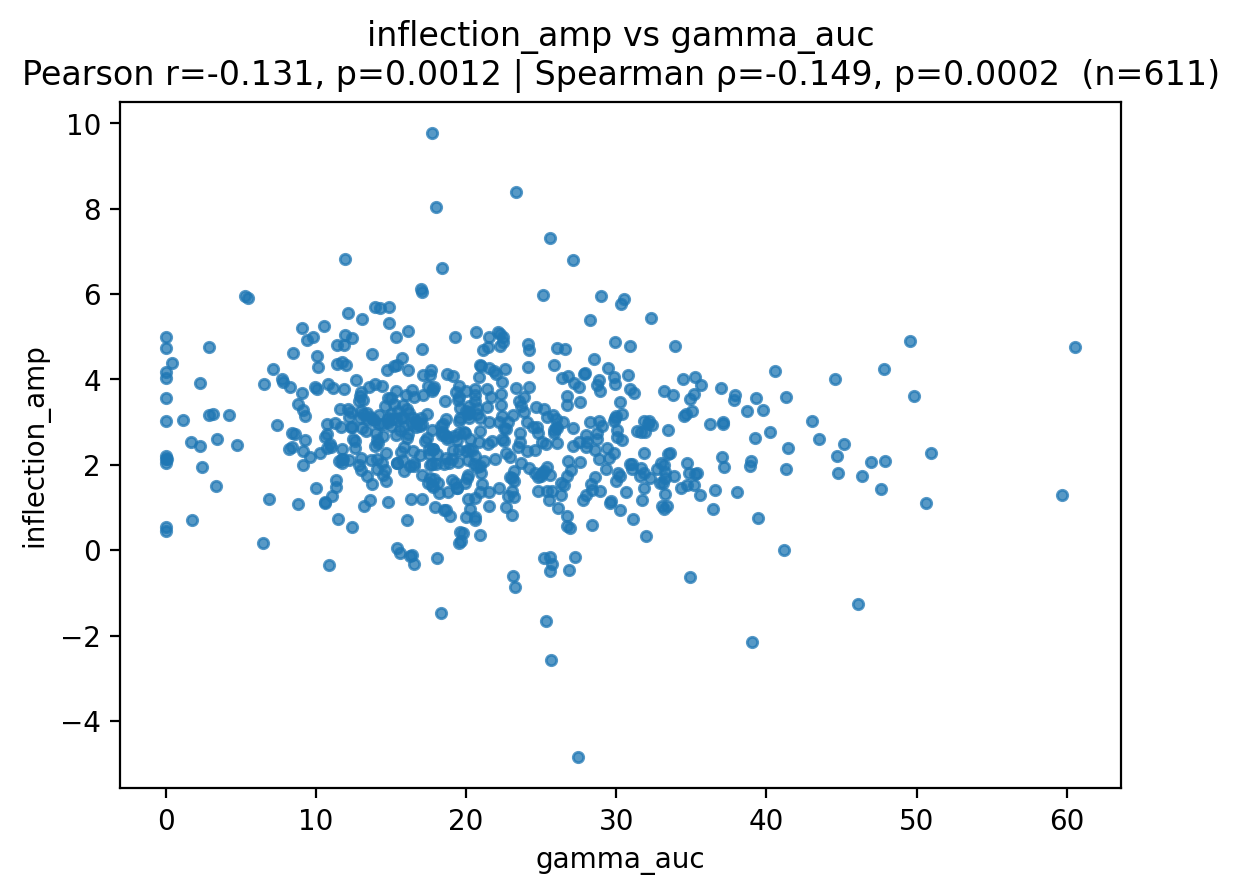

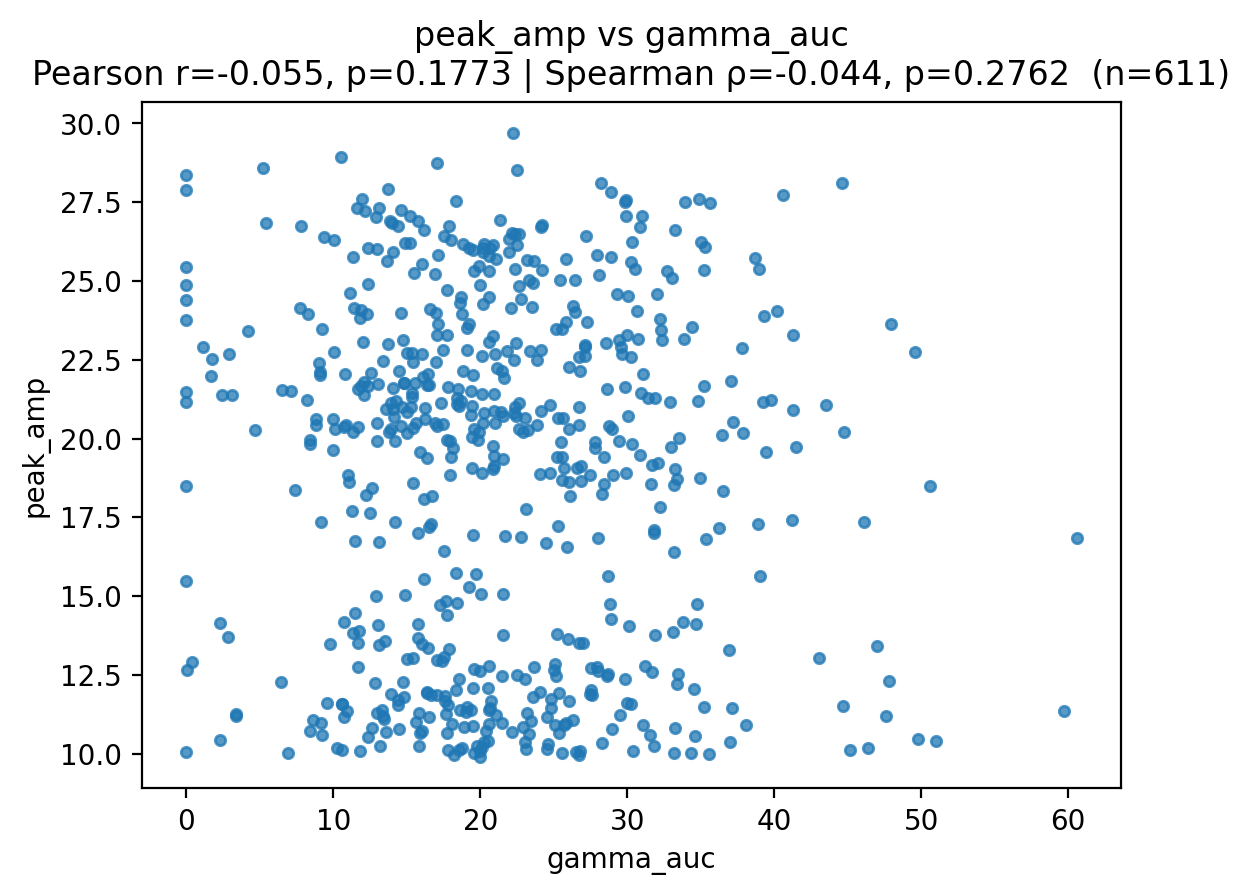

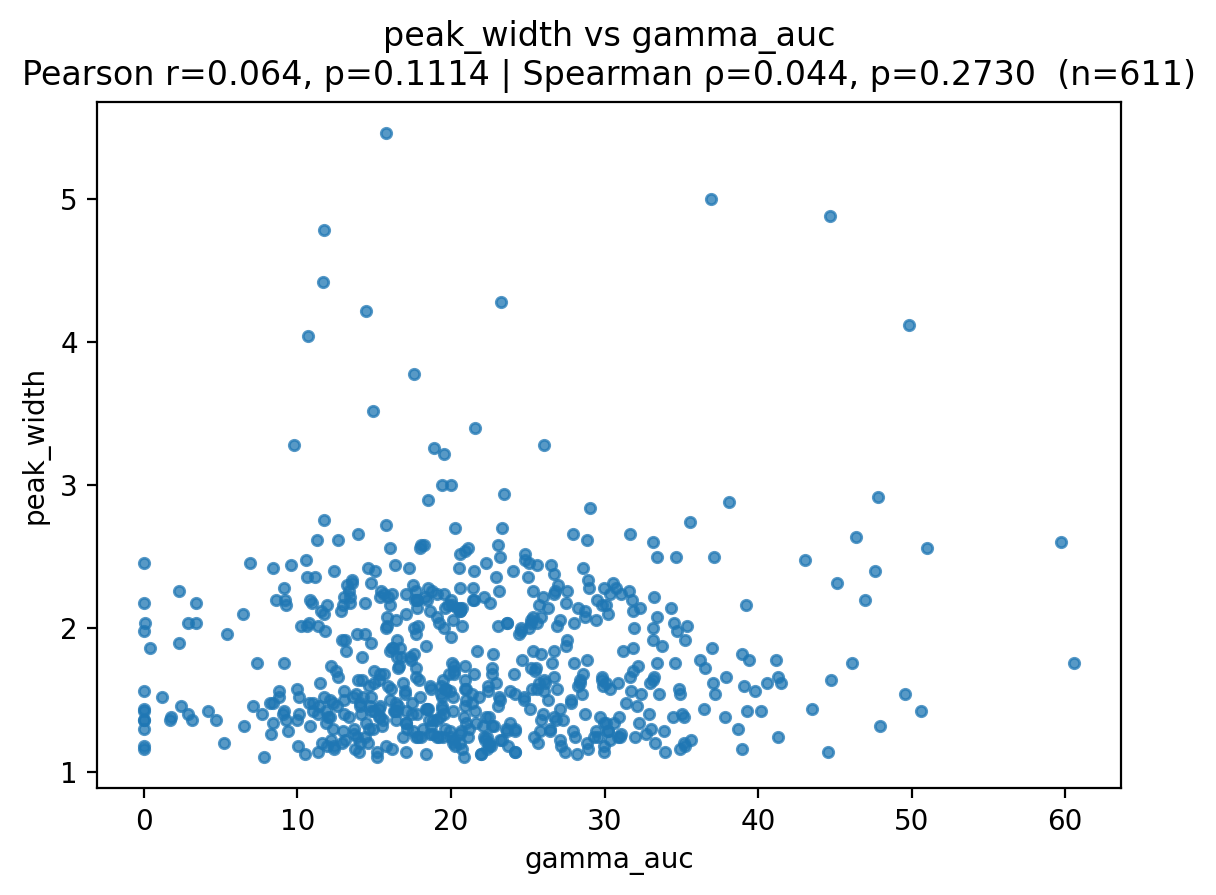

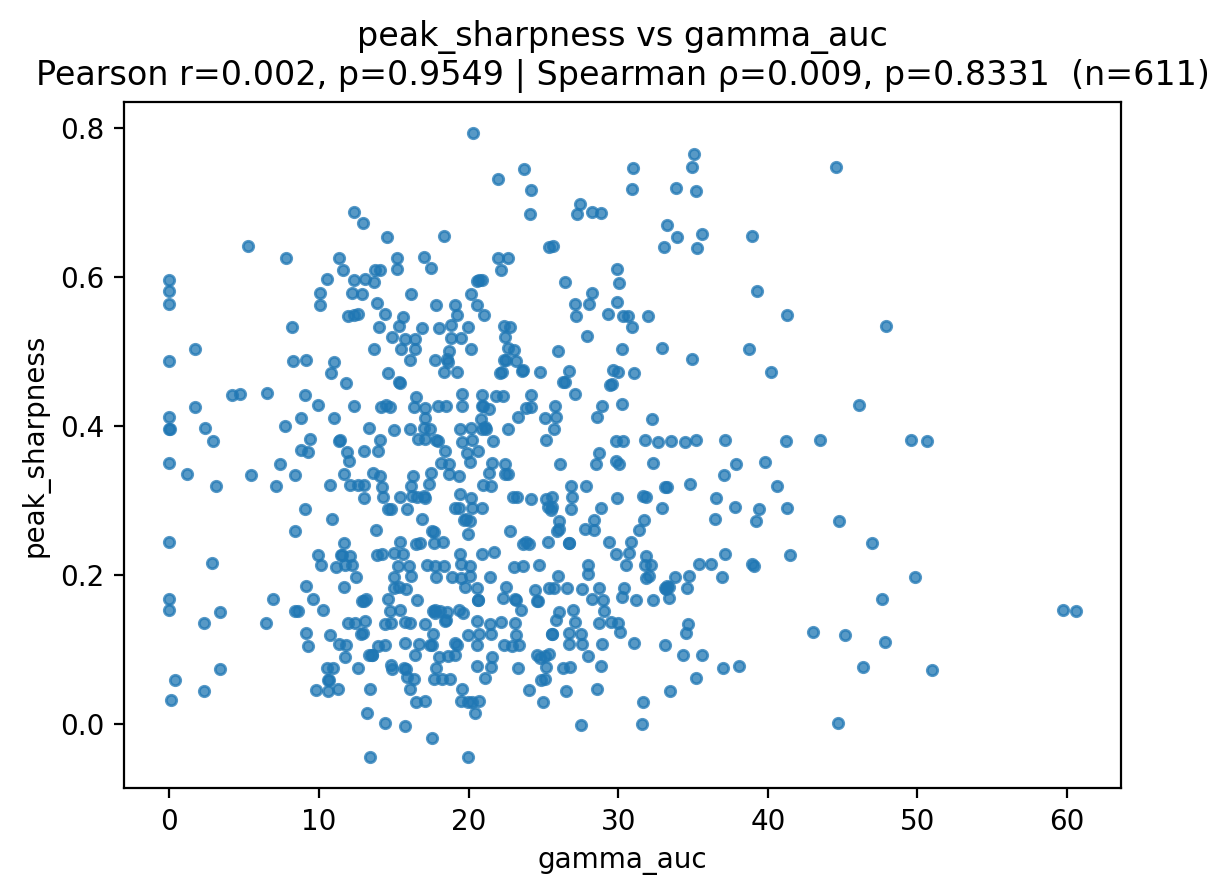

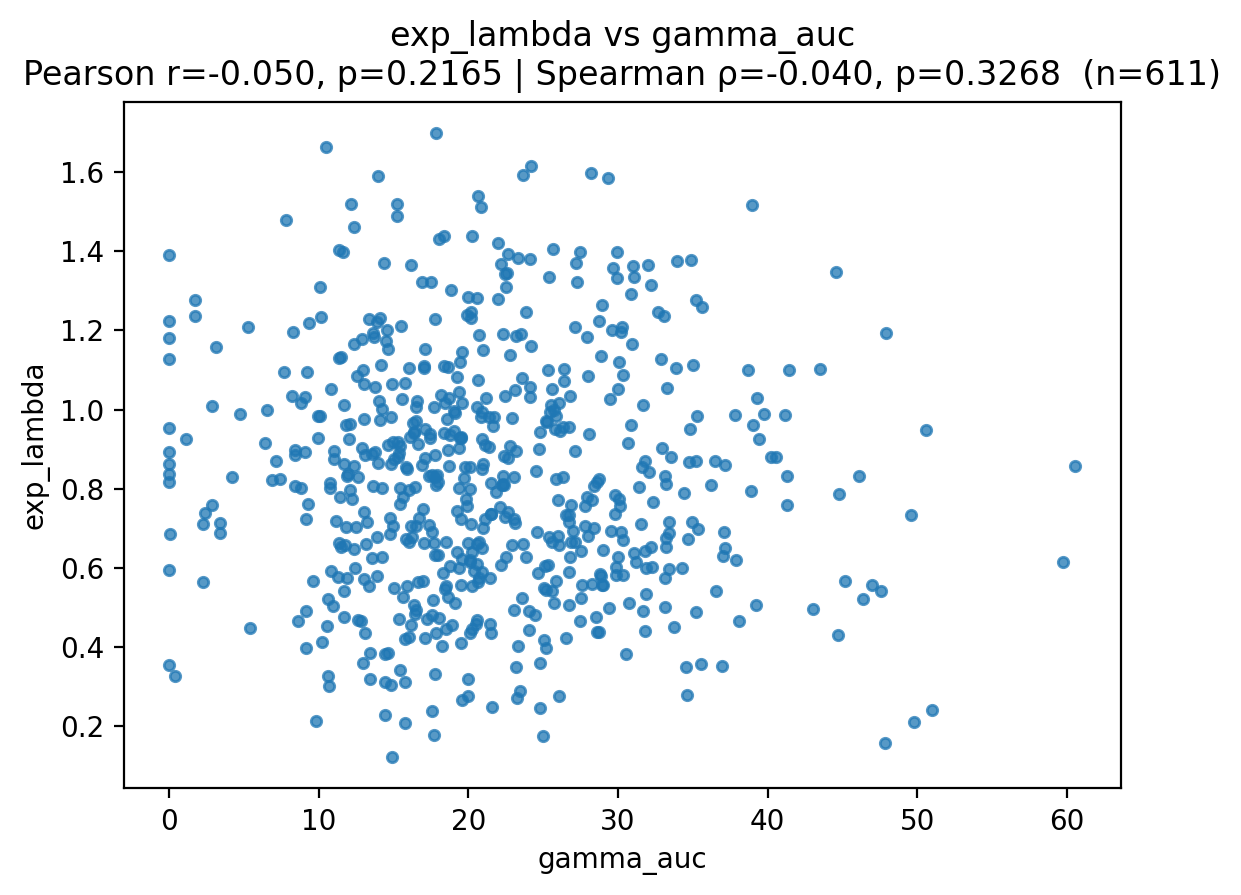

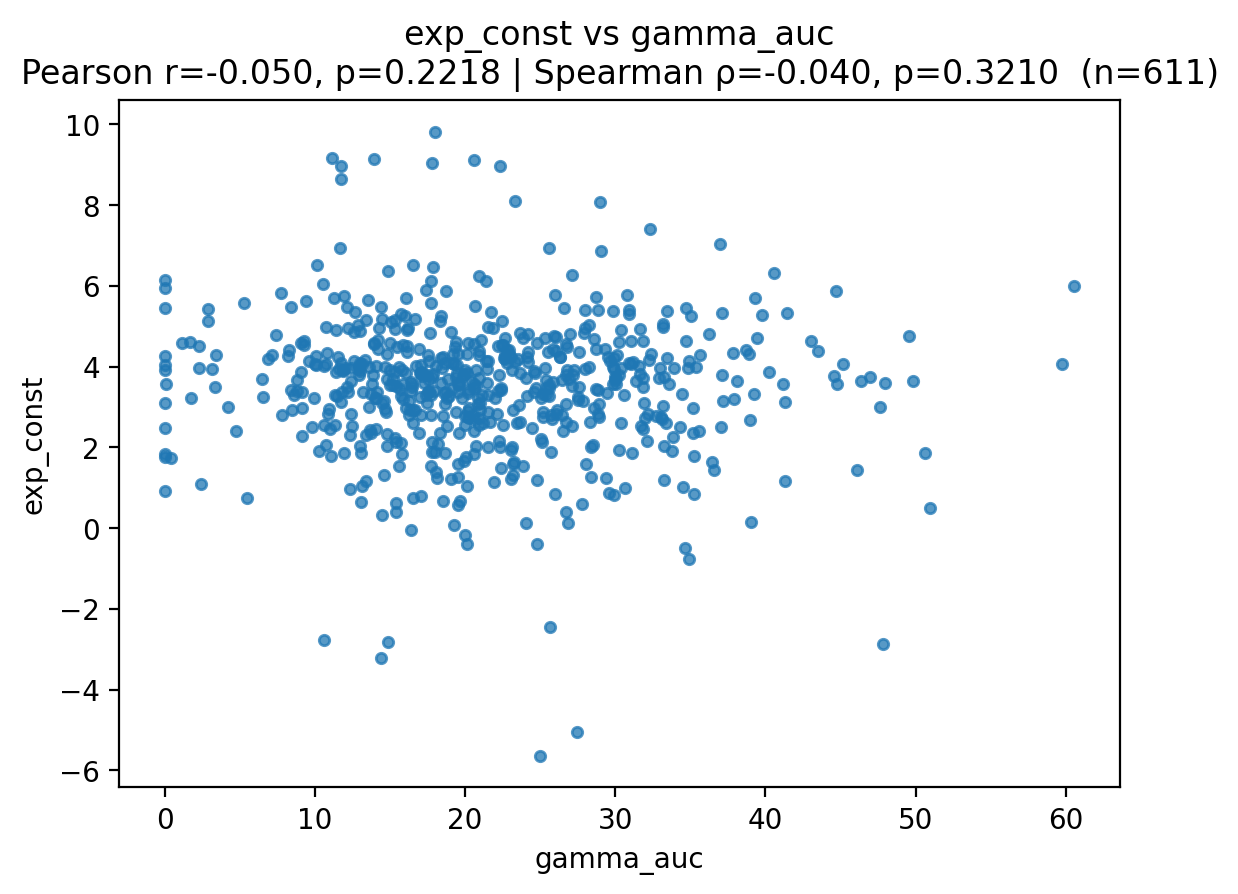

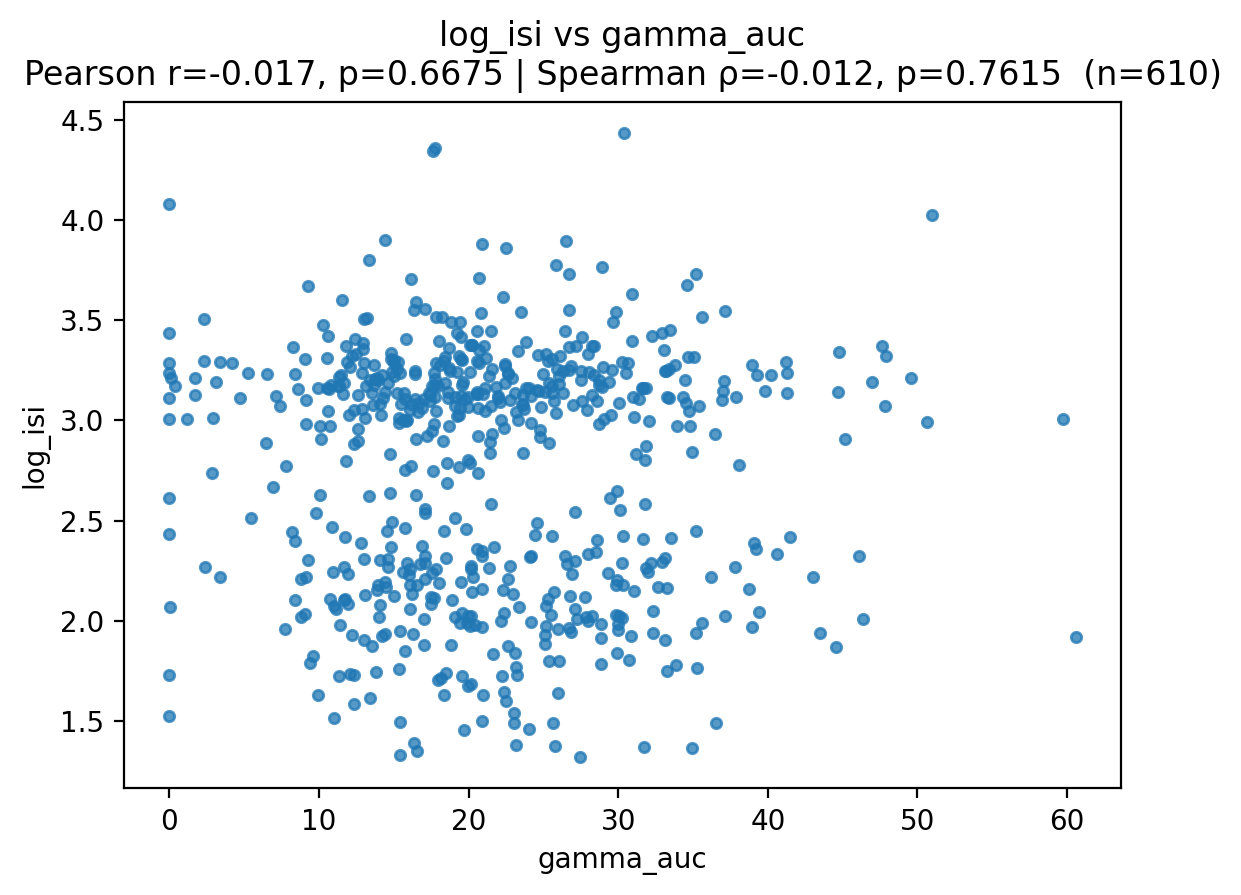

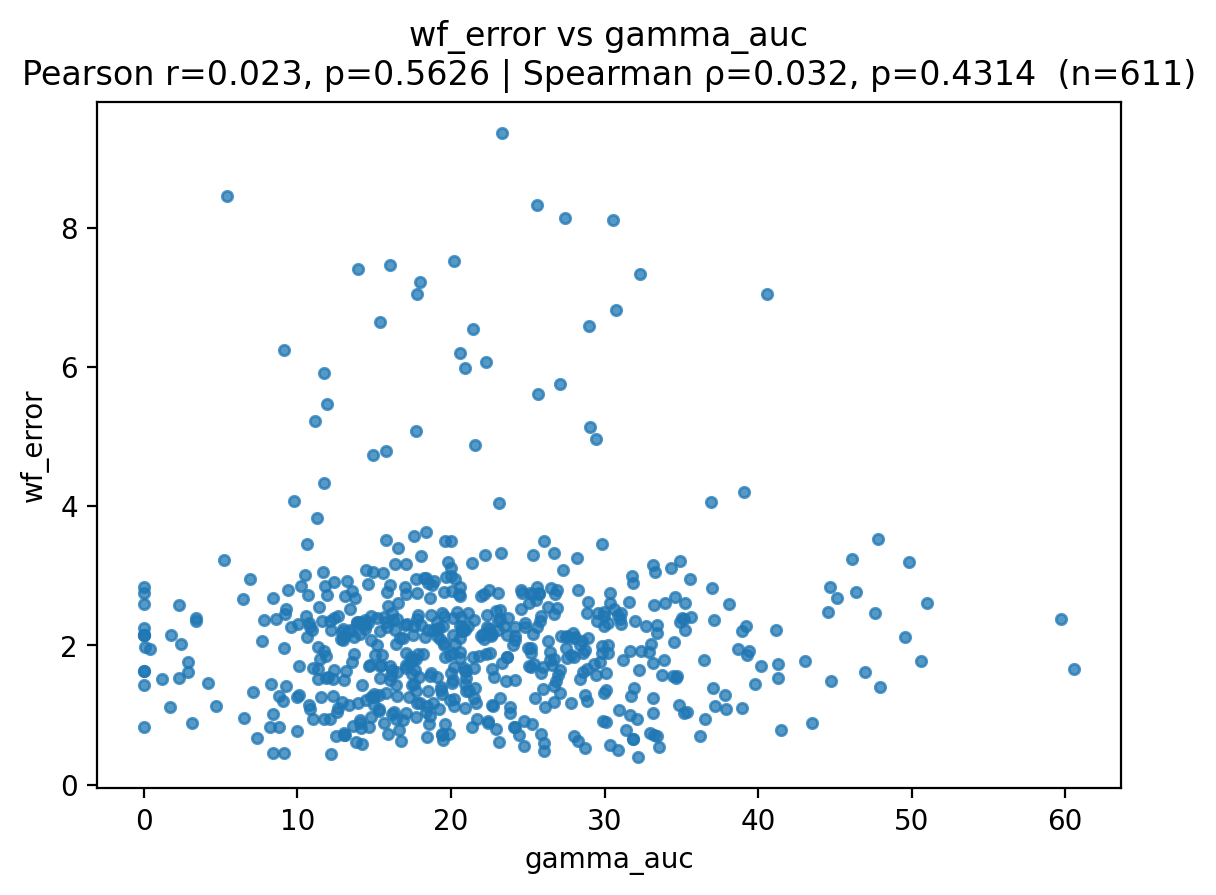

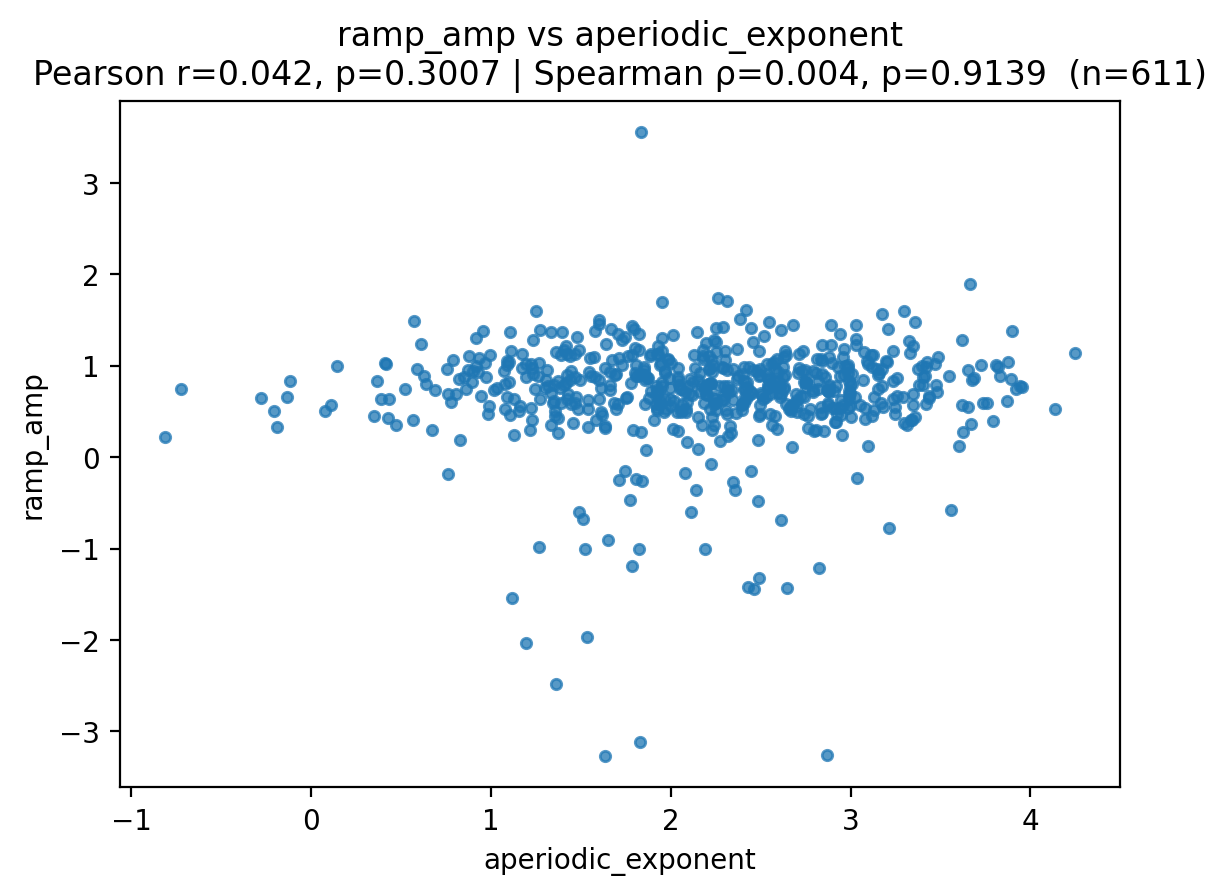

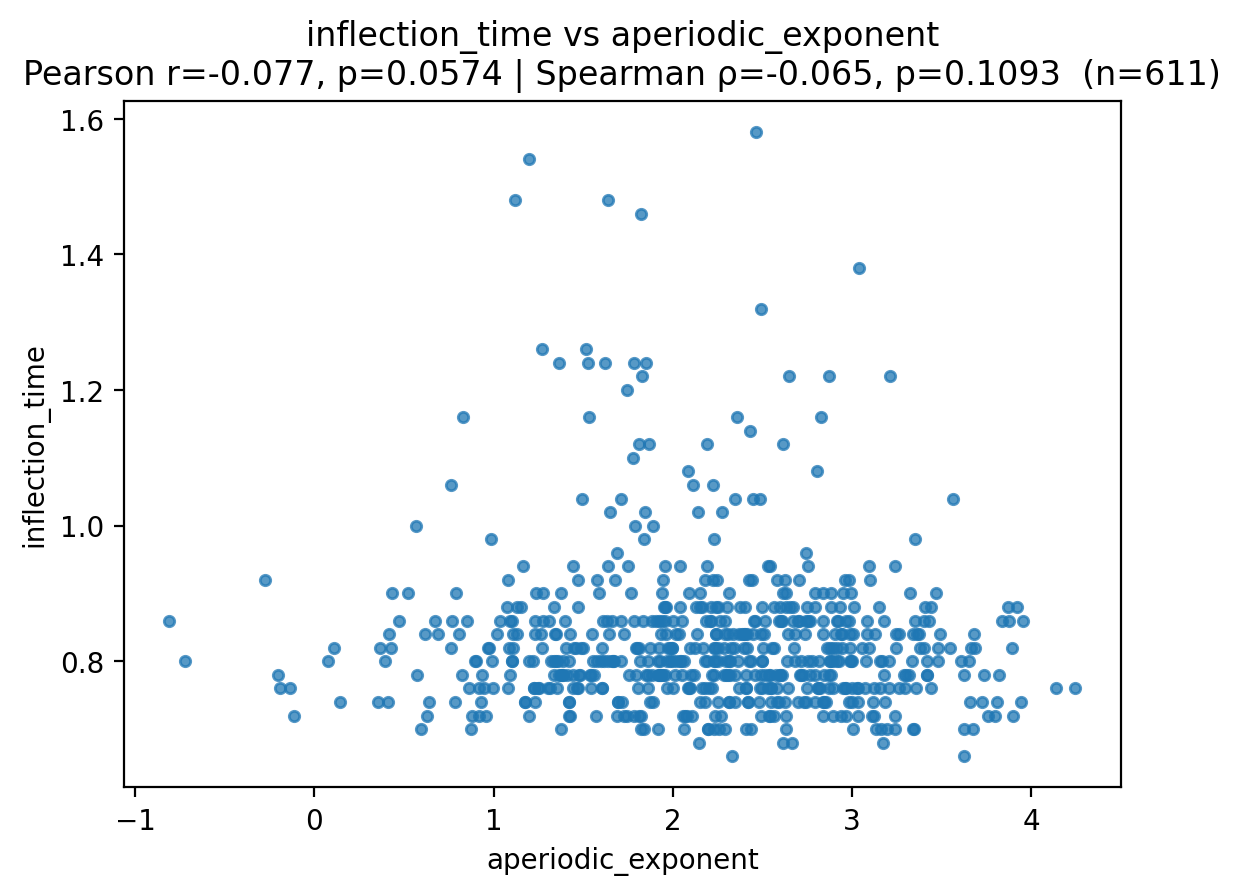

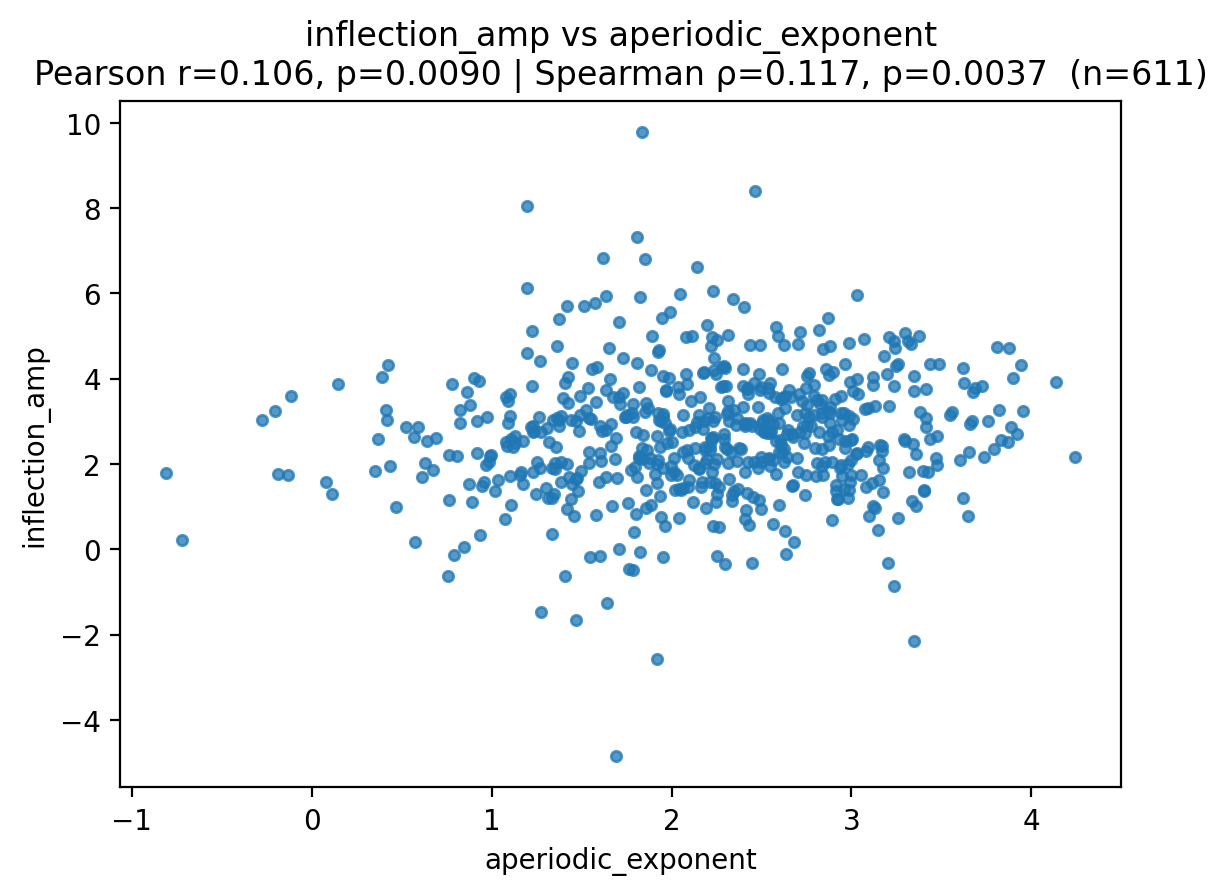

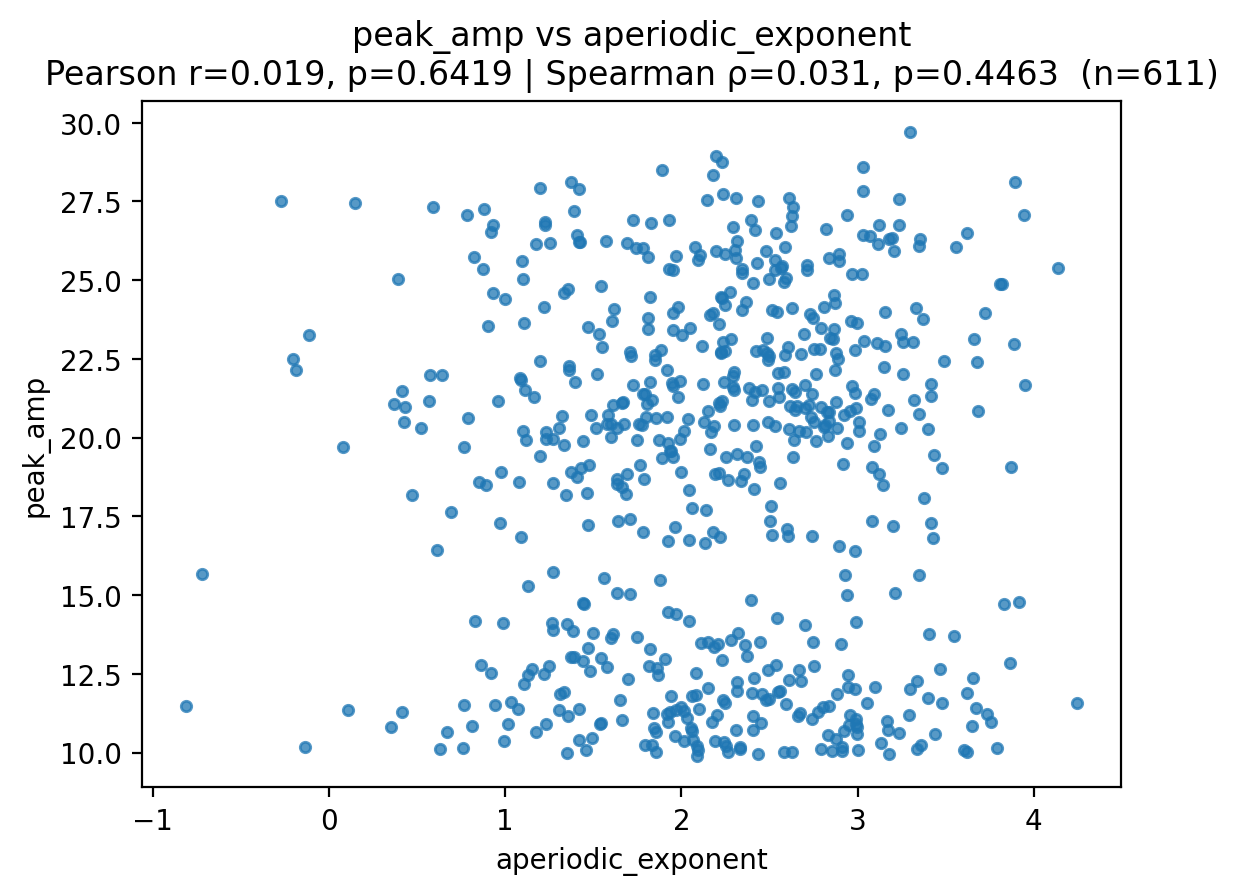

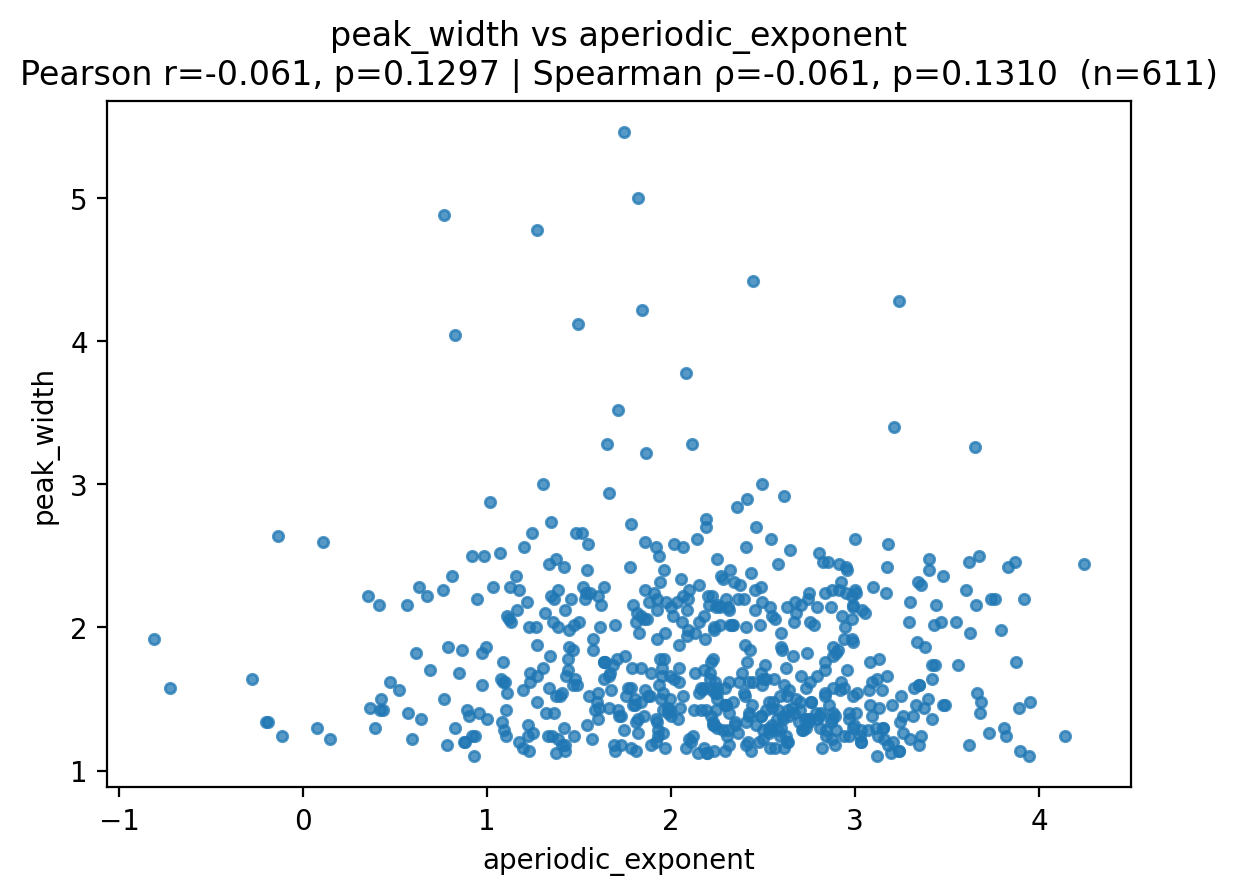

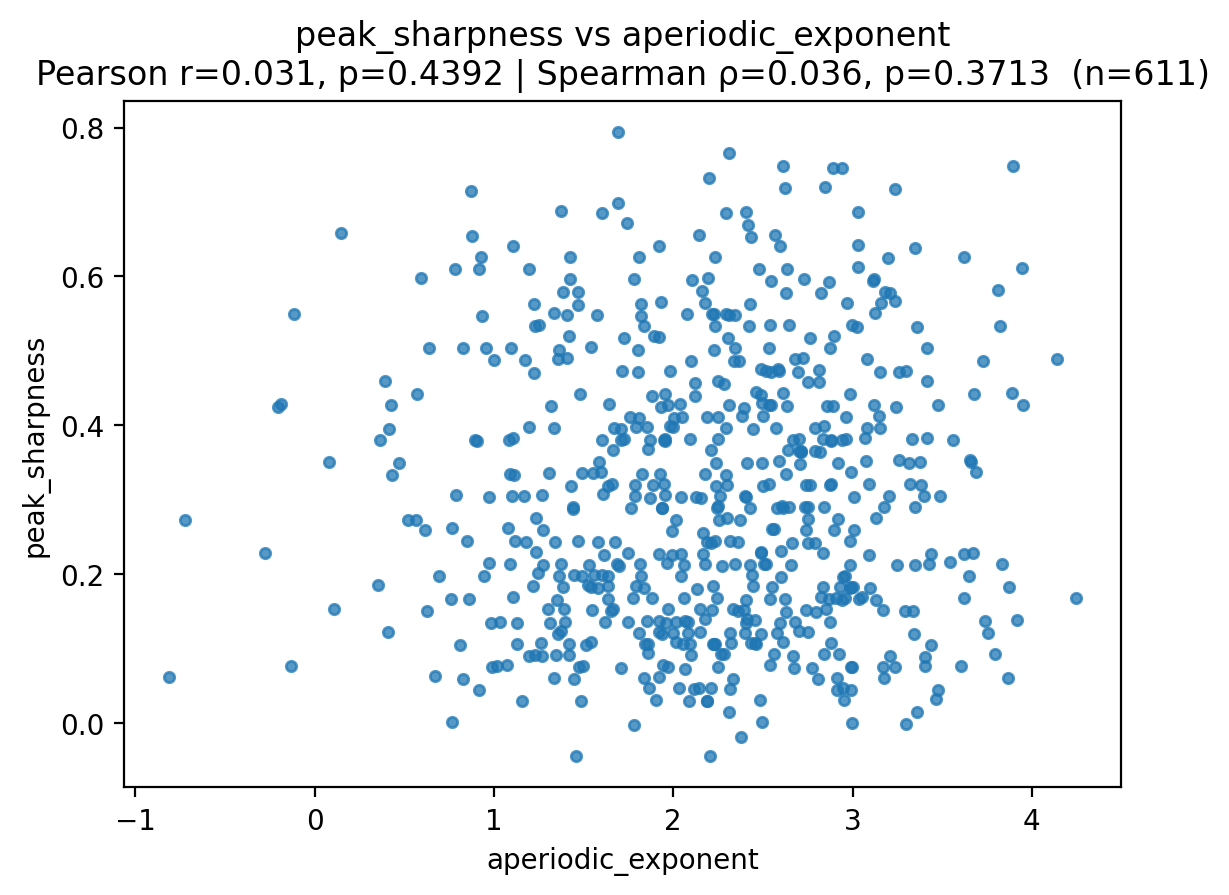

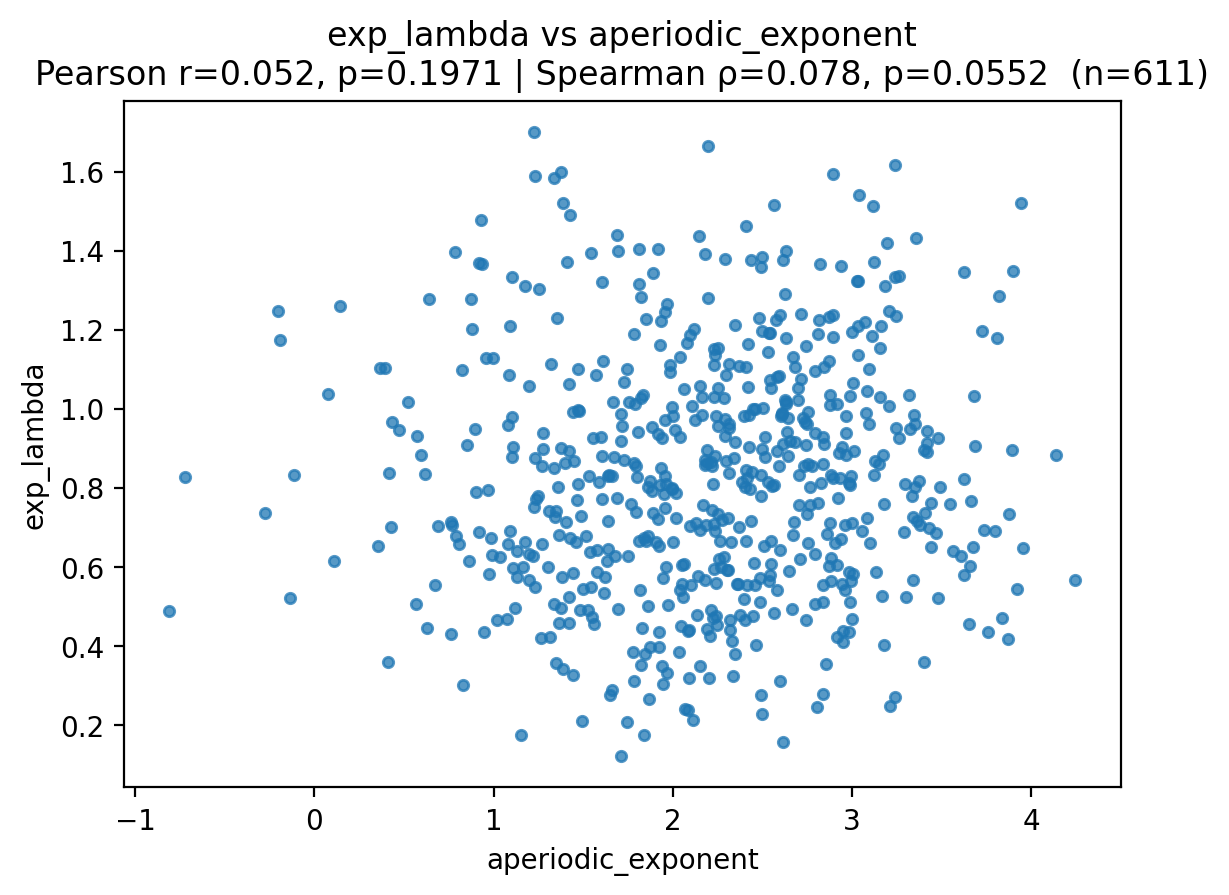

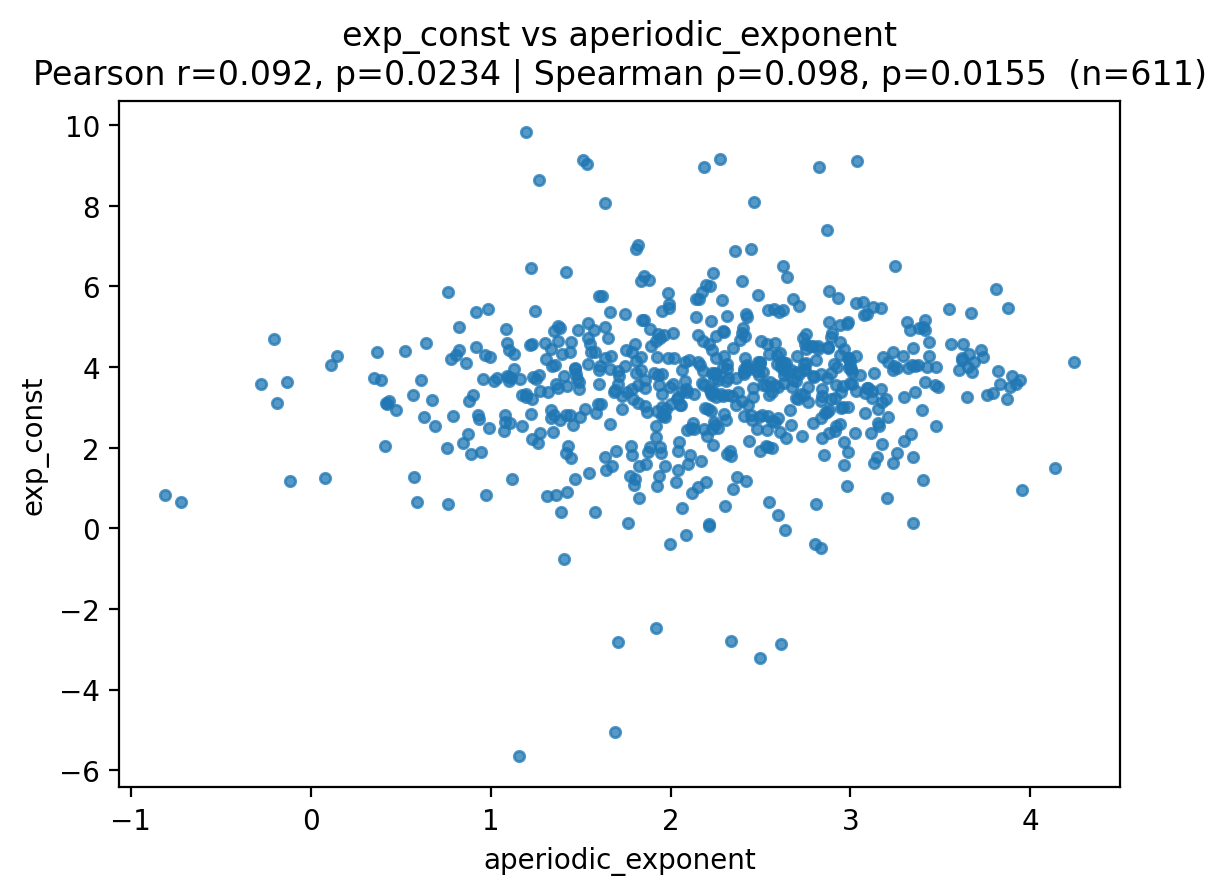

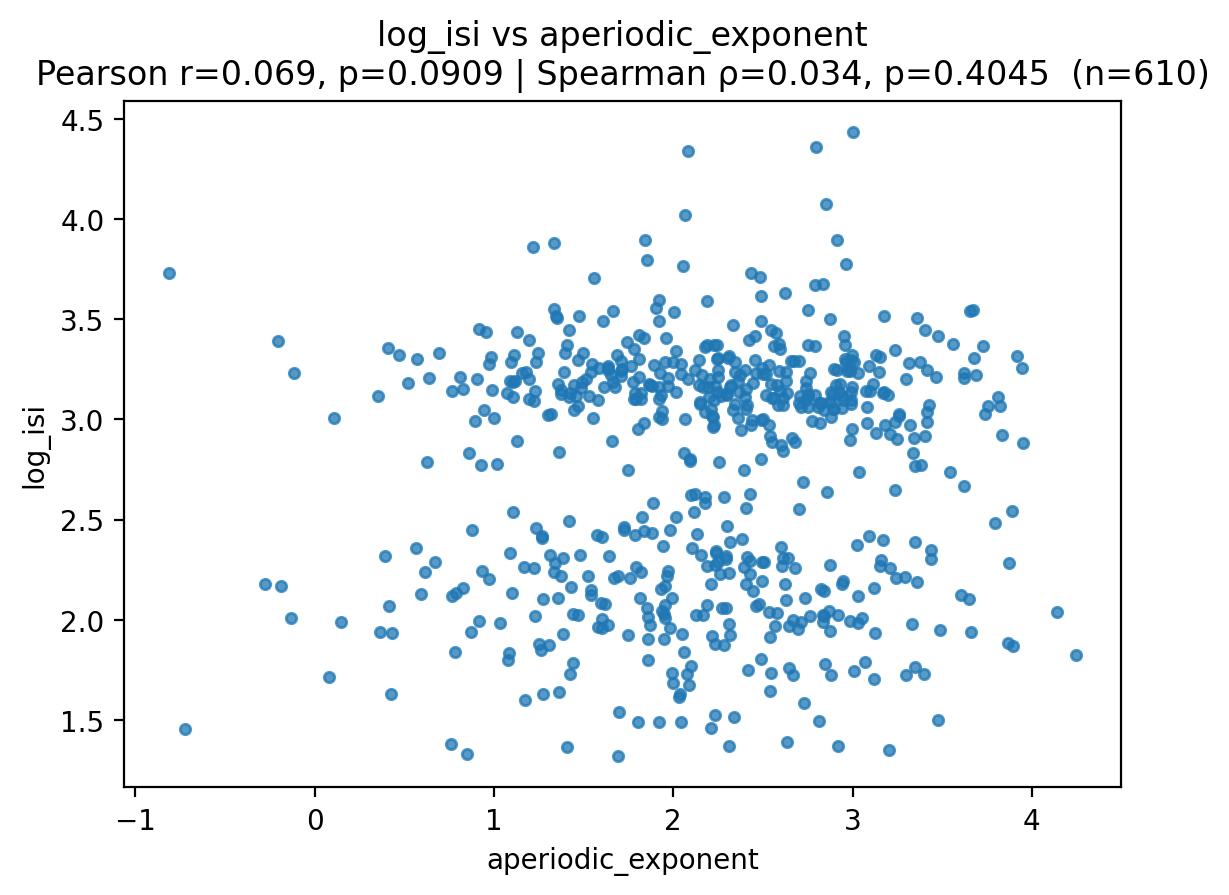

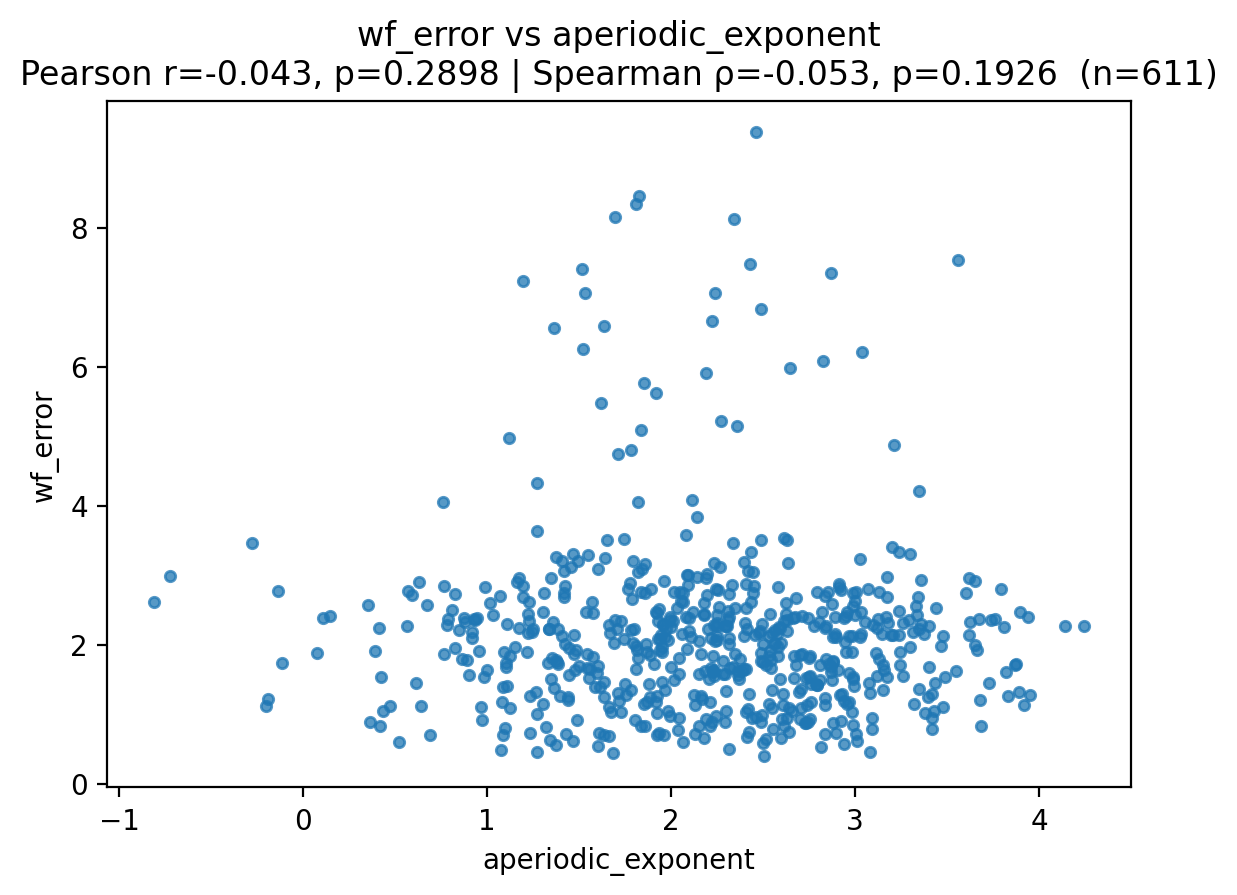

In [443]:
#look for correlations 

from scipy.stats import pearsonr, spearmanr

df = spike_lfp_with_feats  # your merged dataframe

lfp_feats   = ["gamma_auc", "aperiodic_exponent"]
spike_feats = [
    "ramp_amp","inflection_time","inflection_amp","peak_amp",
    "peak_width","peak_sharpness","exp_lambda","exp_const","log_isi","wf_error"
]

lfp_feats   = [c for c in lfp_feats   if c in df.columns]
spike_feats = [c for c in spike_feats if c in df.columns]

def fmt_p(p, decimals=4):
    thresh = 10**(-decimals)
    return f"< {thresh:.{decimals}f}" if p < thresh else f"{p:.{decimals}f}"

for x in lfp_feats:
    for y in spike_feats:
        d = df[[x, y]].dropna()
        n = len(d)
        if n < 3:
            continue

        r_p, p_p = pearsonr(d[x], d[y])
        r_s, p_s = spearmanr(d[x], d[y])

        fig, ax = plt.subplots(figsize=(5.8, 4.6))
        ax.scatter(d[x].to_numpy(), d[y].to_numpy(), s=14, alpha=0.75)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.set_title(
            f"{y} vs {x}\n"
            f"Pearson r={r_p:.3f}, p={fmt_p(p_p)} | "
            f"Spearman ρ={r_s:.3f}, p={fmt_p(p_s)}  (n={n})"
        )

       

        plt.tight_layout()
        plt.show()
